# Analytics Project
## Dynamic Pricing and Purchase Prediction - Predicting Order Behaviour in a Mail-Order Pharmacy

### **Group Alpha**

# 1. Introduction

# 2. Business Understanding
## 2.1 Background Information
## 2.2 Business Objective, Risks, and Benefits
## 2.3 Success Criteria and Data Mining Goals
## 2.4 Project Phases and Tools

# 3. Data Understanding
Adding to the foundation of Business Understanding, the Data Understanding phase focuses on identifying, collecting, and analyzing data sets that can help the project. This phase also has four tasks:
1. Collect initial data: Acquire the necessary data and (if necessary) load it into your analysis tool.
2. Describe data: Examine the data and document its surface properties like data format, number of records, or field identities.
3. Explore data: Dig deeper into the data. Query it, visualize it, and identify relationships among the data.
4. Verify data quality: How clean/dirty is the data? Document any quality issues.

## 3.1 Description of the Data

In [1]:
# Core imports for Step 1 pipeline
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Reusable paths
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Unified visualization palette (color-blind friendly) used across the notebook
VIZ_COLORS = {
    "primary": "#1f77b4",
    "primary_light": "#9ecae1",
    "primary_dark": "#0b3c66",
    "highlight": "#ff7f0e",
    "neutral": "#6b7280",
    "neutral_light": "#d1d5db",
    "success": "#2ca02c",
    "danger": "#d62728",
    "grid": "#e5e7eb",
}

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d0d7de",
    "axes.titleweight": "semibold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": VIZ_COLORS["grid"],
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
})

print("Core imports, paths, and visualization theme set up successfully.")

Core imports, paths, and visualization theme set up successfully.


In [2]:
# Load source datasets
train_raw_df = pd.read_csv(DATA_DIR / "train.csv", sep="|")
items_raw_df = pd.read_csv(DATA_DIR / "items.csv", sep="|")

# Minimal schema validation for reproducibility
# A fail-fast schema check is a system design principle that immediately halts processing and throws an error when incoming data violates a predefined schema, preventing corrupt data from propagating. It ensures data integrity by catching issues at the earliest interface—such as during file ingestion or API request validation—rather than allowing failures to break downstream systems.
required_train_cols = {"pid", "click", "basket", "order", "price"}
required_items_cols = {"pid", "manufacturer", "rrp"}

missing_train_cols = required_train_cols - set(train_raw_df.columns)
missing_items_cols = required_items_cols - set(items_raw_df.columns)
if missing_train_cols:
    raise ValueError(f"train.csv missing required columns: {sorted(missing_train_cols)}")
if missing_items_cols:
    raise ValueError(f"items.csv missing required columns: {sorted(missing_items_cols)}")

print("Train shape:", train_raw_df.shape)
print("Items shape:", items_raw_df.shape)
print("Unique pids in train:", train_raw_df["pid"].nunique())
print("Unique pids in items:", items_raw_df["pid"].nunique())

Train shape: (2756003, 11)
Items shape: (22035, 11)
Unique pids in train: 21928
Unique pids in items: 22035


Notes on Output: Not all available products (items.csv) are in the training data (train.csv) or in business context, these products were never clicked, added to the basket or bought.
Potential checks to do:
1. Are events overwritten (When a customer clicks and afterwards adds an item to his basket, is the row in the CSV file overwritten or a new row added)?
2. Which prodcuts are not used?

**Static Product Attributes (items.csv)**

In [3]:
# All numbers should be formatted without scientific notation for readability
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
# new line for better readability of large numbers

print(".head() shows the first 10 rows of the item dataset:")
print(items_raw_df.head(10))
print()
print(".info() provides a concise summary of the DataFrame, including data types and non-null counts:")
print(items_raw_df.info())
print()
print(".describe() provides a statistical summary of the DataFrame:")
print(items_raw_df.describe())
print()
print(".isnull().sum() provides the count of null values in each column:")
print(items_raw_df.isnull().sum())
# We calculate the percentage of missing values for each column to understand the extent of missing data:
missing_percent = (items_raw_df.isnull().sum() / len(items_raw_df)) * 100
print(f"Percentage of missing values in each column:")
print(missing_percent)
print()
print(".value_counts() shows the frequency of unique values in the 'manufacturer' column:")
print(items_raw_df["manufacturer"].value_counts())

.head() shows the first 10 rows of the item dataset:
   pid  manufacturer     group content unit pharmForm  genericProduct  \
0    1             1      2FOI      80   ST       TAB               0   
1    2             1      2FOI      80   ST       Tab               0   
2    3             1      2FOI      10    G       GLO               0   
3    4             1      2FOI      80   ST       TAB               0   
4    5             2  10OJ03JS       8   ST       PUL               0   
5    6             1      2FOI      10    G       GLO               0   
6    7             3     21OKG      15   ST       TRA               0   
7    8             1      2FOI      80   ST       TAB               0   
8    9             1      2FOI      10    G       GLO               0   
9   10             4    12OS2F      30   ST       FTA               0   

   salesIndex  category campaignIndex   rrp  
0          40       NaN           NaN 10.89  
1          40       NaN           NaN 10.89  
2    

**Time-Varying Transactional Data (train.csv)**

In [4]:
# All numbers should be formatted without scientific notation for readability
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
# new line for better readability of large numbers

print(".head() shows the first 10 rows of the train dataset:")
print(train_raw_df.head(10))
print()
print(".info() provides a concise summary of the DataFrame, including data types and non-null counts:")
print(train_raw_df.info())
print()
print(".describe() provides a statistical summary of the DataFrame:")
print(train_raw_df.describe())
print()
print(".isnull().sum() provides the count of null values in each column:")
print(train_raw_df.isnull().sum())
print()
# Calculating the percentage of missing values for each column to understand the extent of missing data:
missing_percent_train = (train_raw_df.isnull().sum() / len(train_raw_df)) * 100
print(f"Percentage of missing values in each column:")
print(missing_percent_train)
print(".click.value_counts() shows the count of each unique value in the 'click' column:")
print(train_raw_df["click"].value_counts())
print()
print(".basket.value_counts() shows the count of each unique value in the 'basket' column:")
print(train_raw_df["basket"].value_counts())
print()
print(".order.value_counts() shows the count of each unique value in the 'order' column:")
print(train_raw_df["order"].value_counts())
print()
print(".price.describe() provides a statistical summary of the 'price' column:")
print(train_raw_df["price"].describe())

.head() shows the first 10 rows of the train dataset:
   lineID  day    pid  adFlag  availability  competitorPrice  click  basket  \
0       1    1   6570       0             2            14.60      1       0   
1       2    1  14922       1             1             8.57      0       1   
2       3    1  16382       0             1            14.77      0       1   
3       4    1   1145       1             1             6.59      0       0   
4       5    1   3394       0             1             4.39      0       0   
5       6    1   3661       0             1            13.66      0       0   
6       7    1   3856       1             1             3.03      0       0   
7       8    1  16963       0             1             8.78      1       0   
8       9    1  14560       0             1            10.84      1       0   
9      10    1   4853       1             1             9.12      1       0   

   order  price  revenue  
0      0  16.89     0.00  
1      0   8.75     0.

## 3.2 Further Data Understanding

**PID Key Integrity Checks**

In [5]:
# Null and duplicate checks for join key pid
train_pid_null_count = int(train_raw_df["pid"].isna().sum())
items_pid_null_count = int(items_raw_df["pid"].isna().sum())

if train_pid_null_count > 0:
    raise ValueError(f"train.csv has {train_pid_null_count} null pid values")

if items_pid_null_count > 0:
    raise ValueError(f"items.csv has {items_pid_null_count} null pid values")

duplicate_pid_count = int(items_raw_df["pid"].duplicated().sum())
if duplicate_pid_count > 0:
    raise ValueError(
        f"items.csv contains {duplicate_pid_count} duplicated pid values; expected unique pid for m:1 merge"
    )

print("All schema and data integrity checks passed successfully.")

All schema and data integrity checks passed successfully.


**Merge Dataset train.csv and items.csv**

In [6]:
# Left join on pid to enrich train data with item attributes
# Learning: validate="m:1" enforces that each pid in train_raw_df matches at most one pid in items_raw_df, ensuring no unintended duplication of rows.
train_item_set = train_raw_df.merge(items_raw_df, on="pid", how="left", validate="m:1")

print("Successfully merged train and items datasets.")

Successfully merged train and items datasets.


**Validation Checks after Merge**

In [7]:
# Validation checks: row/column counts, missing values, and mutual exclusivity of click/basket/order
# Learning: isna vs isnull - both methods are equivalent for pandas DataFrames; isna is an alias for isnull. Using isna() for consistency with pandas documentation and readability.
row_count = int(train_item_set.shape[0])
column_count = int(train_item_set.shape[1])
missing_values = train_item_set.isna().sum().sort_values(ascending=False)

# Strict mutual exclusivity: exactly one of click/basket/order must be 1
action_cols = ["click", "basket", "order"]
action_sum = train_item_set[action_cols].sum(axis=1)
mutual_exclusive_exact = bool((action_sum == 1).all())
violating_rows = int((action_sum != 1).sum())

# Expected parity values from Step 1 baseline
expected = {
    "row_count": 2756003,
    "column_count": 21,
    "mutual_exclusive_exact": True,
}
parity_ok = (
    row_count == expected["row_count"]
    and column_count == expected["column_count"]
    and mutual_exclusive_exact == expected["mutual_exclusive_exact"]
)
if not parity_ok:
    raise AssertionError(
        "Parity check failed. Review source data and merge logic before continuing."
    )

# Persist canonical Step 1 artifacts
merged_out = PROCESSED_DIR / "step1_merged_baseline.csv"
missing_out = PROCESSED_DIR / "step1_missing_values.csv"
summary_out = PROCESSED_DIR / "step1_validation_summary.json"

# Control large-file rewrites explicitly
FORCE_REFRESH_BASELINE = False

# Keep missing report compact but always write a stable CSV schema
missing_report = (
    missing_values[missing_values > 0]
    .rename_axis("column")
    .reset_index(name="missing_count")
)
if missing_report.empty:
    missing_report = pd.DataFrame({"column": [], "missing_count": []})
missing_report.to_csv(missing_out, index=False)

# Write merged baseline only on first run, unless refresh is requested
if FORCE_REFRESH_BASELINE or not merged_out.exists():
    train_item_set.to_csv(merged_out, index=False)

summary_payload = {
    "row_count": row_count,
    "column_count": column_count,
    "mutual_exclusive_exact": mutual_exclusive_exact,
    "violating_rows": violating_rows,
    "parity_ok": parity_ok,
    "expected": expected,
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "artifacts": {
        "merged": str(merged_out),
        "missing_values": str(missing_out),
        "summary": str(summary_out),
    },
}

with summary_out.open("w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2, sort_keys=True)

print("Row count:", row_count)
print("Column count:", column_count)
print("Rows violating action exclusivity:", violating_rows)
print("Click/basket/order mutual exclusivity (exactly one):", mutual_exclusive_exact)
print("Step 1 parity with baseline:", parity_ok)
print("\nTop missing values:")
print(missing_values.head(10))
print("\nValidation summary:")
print(json.dumps(summary_payload, indent=2))

Row count: 2756003
Column count: 21
Rows violating action exclusivity: 0
Click/basket/order mutual exclusivity (exactly one): True
Step 1 parity with baseline: True

Top missing values:
campaignIndex      2287968
pharmForm           194124
competitorPrice     100687
category             87394
lineID                   0
availability             0
adFlag                   0
pid                      0
day                      0
price                    0
dtype: int64

Validation summary:
{
  "row_count": 2756003,
  "column_count": 21,
  "mutual_exclusive_exact": true,
  "violating_rows": 0,
  "parity_ok": true,
  "expected": {
    "row_count": 2756003,
    "column_count": 21,
    "mutual_exclusive_exact": true
  },
  "generated_at_utc": "2026-04-17T12:47:58.525228+00:00",
  "artifacts": {
    "merged": "data/processed/step1_merged_baseline.csv",
    "missing_values": "data/processed/step1_missing_values.csv",
    "summary": "data/processed/step1_validation_summary.json"
  }
}


/var/folders/3p/m3yt82xn6wn0mbp1wnz1p19c0000gn/T/ipykernel_23267/2428946334.py:58: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "generated_at_utc": pd.Timestamp.utcnow().isoformat(),


**Exploration of the target variable 'order'**

Distribution of the target variable 'order':
order
0    2050913
1     705090
Name: count, dtype: int64

Percentage distribution of 'order':
order
0   74.42
1   25.58
Name: count, dtype: float64

Class imbalance summary:
Majority class: 0 (2,050,913)
Minority class: 1 (705,090)
Imbalance ratio (majority/minority): 2.91:1
No-order rate: 74.42% | Order rate: 25.58%
Majority-class baseline accuracy: 0.7442
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/order_distribution.png


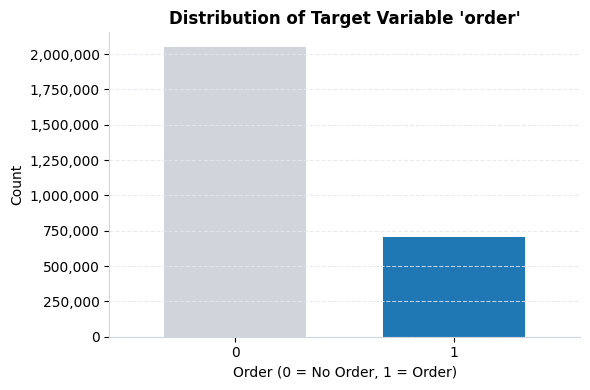

PosixPath('figures/order_distribution.png')

In [8]:
# Show statistical representation of all numbers in the DataFrame without scientific notation for better readability
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

viz = globals().get(
    "VIZ_COLORS",
    {
        "primary": "#1f77b4",
        "neutral_light": "#d1d5db",
        "grid": "#e5e7eb",
    },
)

# Exploration of the target variable 'order'
print("Distribution of the target variable 'order':")
order_counts = train_raw_df["order"].value_counts().sort_index()
print(order_counts)
print()
print("Percentage distribution of 'order':")
order_percent = (order_counts / len(train_raw_df)) * 100
print(order_percent)

# Explicit imbalance metrics
majority_count = int(order_counts.max())
minority_count = int(order_counts.min())
majority_class = int(order_counts.idxmax())
minority_class = int(order_counts.idxmin())

imbalance_ratio = majority_count / minority_count
order_rate_pct = float(order_percent.get(1, 0.0))
no_order_rate_pct = float(order_percent.get(0, 0.0))
baseline_majority_accuracy = max(order_percent) / 100

print()
print("Class imbalance summary:")
print(f"Majority class: {majority_class} ({majority_count:,})")
print(f"Minority class: {minority_class} ({minority_count:,})")
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}:1")
print(f"No-order rate: {no_order_rate_pct:.2f}% | Order rate: {order_rate_pct:.2f}%")
print(f"Majority-class baseline accuracy: {baseline_majority_accuracy:.4f}")

# Plot
class_colors = {0: viz["neutral_light"], 1: viz["primary"]}
bar_colors = [class_colors.get(int(c), viz["neutral_light"]) for c in order_counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
order_counts.plot(kind="bar", color=bar_colors, width=0.65, ax=ax)
ax.set_title("Distribution of Target Variable 'order'")
ax.set_xlabel("Order (0 = No Order, 1 = Order)")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.8, color=viz["grid"])

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename: str, dpi: int = 300) -> Path:
    out_path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    if not out_path.exists():
        raise FileNotFoundError(f"Figure was not saved: {out_path}")
    print(f"Saved figure to: {out_path.resolve()}")
    plt.show()
    plt.close(fig)
    return out_path

save_and_show(fig, "order_distribution.png")

**Funnel Analysis**

Rows: 2,756,003
Mutual exclusivity (exactly one of click/basket/order = 1): True
Violating rows: 0

=== Observed Funnel (Event Shares) ===
 stage   count  rate_percent  from_prev_ratio  from_prev_percent  drop_from_prev_percent
 click 1582827         57.43              NaN                NaN                     NaN
basket  468086         16.98             0.30              29.57                   70.43
 order  705090         25.58             1.51             150.63                  -50.63

Observed key ratios:
basket/click: 0.2957
order/basket: 1.5063
order/click: 0.4455

Saved table: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/funnel_observed.csv
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/funnel_observed.png


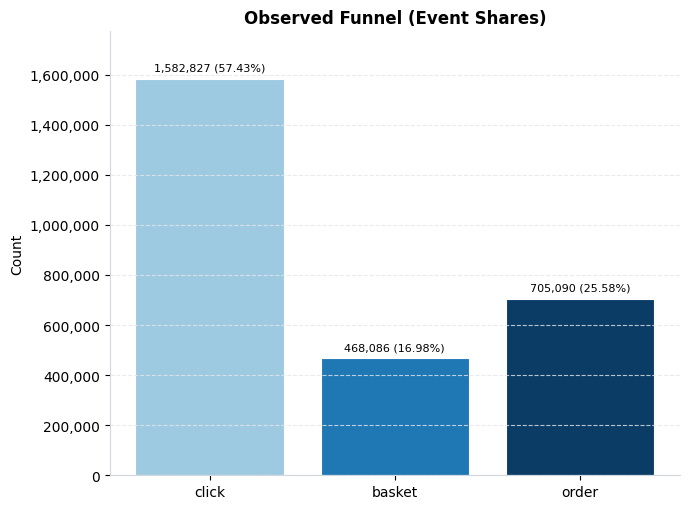


=== Overwrite-Adjusted Funnel (3/2/1) ===
 stage  click_component  basket_component  order_component  backward_total  backward_rate_percent  from_prev_ratio_backward  from_prev_percent_backward
 click          1582827            468086           705090         2756003                 100.00                       NaN                         NaN
basket                0            468086           705090         1173176                  42.57                      0.43                       42.57
 order                0                 0           705090          705090                  25.58                      0.60                       60.10

Adjusted key ratios:
basket_exposure/click_exposure: 0.4257
order/basket_exposure: 0.6010
order/click_exposure: 0.2558

Saved table: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/funnel_backward_added_321.csv
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/funnel_backward_added_321.png


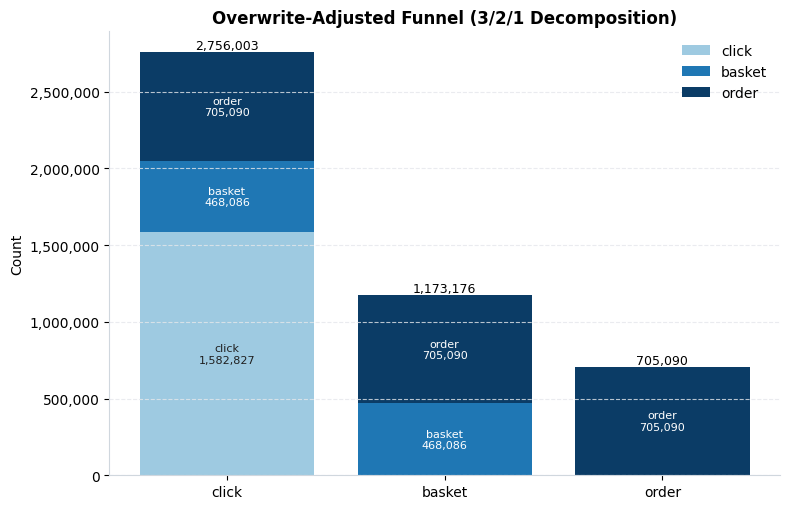

In [9]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Funnel Analysis (Observed + Overwrite-Adjusted 3/2/1)
# ============================================================

viz = globals().get(
    "VIZ_COLORS",
    {
        "primary": "#1f77b4",
        "primary_light": "#9ecae1",
        "primary_dark": "#0b3c66",
        "neutral": "#6b7280",
        "grid": "#e5e7eb",
    },
)

# Required input:
# - train_raw_df with binary columns: click, basket, order
STAGES = ["click", "basket", "order"]

FIGURES_DIR = Path("figures")
PROCESSED_DIR = Path("data/processed")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MIN_LABEL_HEIGHT_PCT = 0.01  # label tiny segments outside if needed


def save_and_show(fig, filename, dpi=300):
    out_path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    if not out_path.exists():
        raise FileNotFoundError(f"Figure was not saved: {out_path}")
    print(f"Saved figure to: {out_path.resolve()}")
    plt.show()
    plt.close(fig)
    return out_path


def validate_binary_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    invalid = {}
    for c in cols:
        vals = set(df[c].dropna().unique())
        bad = vals - {0, 1}
        if bad:
            invalid[c] = sorted(bad)

    if invalid:
        raise ValueError(f"Columns must be binary (0/1). Invalid values found: {invalid}")


def safe_div(num, den):
    return float(num / den) if den != 0 else np.nan


def label_stack_segments(ax, x_pos, bottoms, heights, label, color, min_visible_height):
    for x, b, h in zip(x_pos, bottoms, heights):
        if h <= 0:
            continue
        if h < min_visible_height:
            y = b + h + min_visible_height * 0.35
            va = "bottom"
        else:
            y = b + h / 2
            va = "center"

        ax.text(
            x,
            y,
            f"{label}\n{int(h):,}",
            ha="center",
            va=va,
            fontsize=8,
            color=color,
        )


# ----------------------------
# Validation
# ----------------------------
validate_binary_columns(train_raw_df, STAGES)

total_rows = len(train_raw_df)
if total_rows == 0:
    raise ValueError("train_raw_df is empty. Funnel analysis cannot be computed.")

action_sum = train_raw_df[STAGES].sum(axis=1)
exclusivity_ok = bool((action_sum == 1).all())
violating_rows = int((action_sum != 1).sum())

print(f"Rows: {total_rows:,}")
print(f"Mutual exclusivity (exactly one of click/basket/order = 1): {exclusivity_ok}")
print(f"Violating rows: {violating_rows:,}")
print()


# ----------------------------
# 1) Observed Funnel (event-share)
# ----------------------------
stage_counts = train_raw_df[STAGES].sum().astype("int64")
stage_rates = (stage_counts / total_rows * 100).round(2)

funnel_observed = pd.DataFrame({
    "stage": STAGES,
    "count": stage_counts.reindex(STAGES).values,
    "rate_percent": stage_rates.reindex(STAGES).values,
})

funnel_observed["from_prev_ratio"] = funnel_observed["count"] / funnel_observed["count"].shift(1)
funnel_observed["from_prev_percent"] = (funnel_observed["from_prev_ratio"] * 100).round(2)
funnel_observed["drop_from_prev_percent"] = ((1 - funnel_observed["from_prev_ratio"]) * 100).round(2)
funnel_observed.loc[0, ["from_prev_ratio", "from_prev_percent", "drop_from_prev_percent"]] = pd.NA

# Key observed ratios
obs_basket_click = safe_div(stage_counts["basket"], stage_counts["click"])
obs_order_basket = safe_div(stage_counts["order"], stage_counts["basket"])
obs_order_click = safe_div(stage_counts["order"], stage_counts["click"])

print("=== Observed Funnel (Event Shares) ===")
print(funnel_observed.to_string(index=False))
print()
print("Observed key ratios:")
print(f"basket/click: {obs_basket_click:.4f}")
print(f"order/basket: {obs_order_basket:.4f}")
print(f"order/click: {obs_order_click:.4f}")
print()

funnel_observed.to_csv(PROCESSED_DIR / "funnel_observed.csv", index=False)
print(f"Saved table: {(PROCESSED_DIR / 'funnel_observed.csv').resolve()}")


# Plot observed
stage_colors = [viz["primary_light"], viz["primary"], viz["primary_dark"]]
fig1, ax1 = plt.subplots(figsize=(7, 5.2))
bars1 = ax1.bar(
    funnel_observed["stage"],
    funnel_observed["count"],
    color=stage_colors,
    edgecolor="white",
    linewidth=0.8,
)

ax1.set_title("Observed Funnel (Event Shares)")
ax1.set_ylabel("Count")
ax1.grid(axis="y", alpha=0.8, color=viz["grid"])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

ymax = float(funnel_observed["count"].max())
if ymax > 0:
    ax1.set_ylim(0, ymax * 1.12)
    y_offset = ymax * 0.015
else:
    y_offset = 0.0

for rect, pct in zip(bars1, funnel_observed["rate_percent"]):
    h = float(rect.get_height())
    ax1.text(
        rect.get_x() + rect.get_width() / 2,
        h + y_offset,
        f"{int(h):,} ({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=8,
        clip_on=False,
    )

save_and_show(fig1, "funnel_observed.png")


# ----------------------------
# 2) Overwrite-Adjusted Funnel (3/2/1 decomposition)
# Assumption:
# - order implies basket + click
# - basket implies click
# ----------------------------
if exclusivity_ok:
    click_only = int(stage_counts["click"])
    basket_only = int(stage_counts["basket"])
    order_only = int(stage_counts["order"])

    funnel_adjusted = pd.DataFrame({
        "stage": STAGES,
        "click_component": [click_only, 0, 0],
        "basket_component": [basket_only, basket_only, 0],
        "order_component": [order_only, order_only, order_only],
    })

    funnel_adjusted["backward_total"] = (
        funnel_adjusted["click_component"]
        + funnel_adjusted["basket_component"]
        + funnel_adjusted["order_component"]
    )
    funnel_adjusted["backward_rate_percent"] = (funnel_adjusted["backward_total"] / total_rows * 100).round(2)
    funnel_adjusted["from_prev_ratio_backward"] = (
        funnel_adjusted["backward_total"] / funnel_adjusted["backward_total"].shift(1)
    )
    funnel_adjusted["from_prev_percent_backward"] = (funnel_adjusted["from_prev_ratio_backward"] * 100).round(2)
    funnel_adjusted.loc[0, ["from_prev_ratio_backward", "from_prev_percent_backward"]] = pd.NA

    # Key adjusted ratios (recommended for overwrite interpretation)
    adj_click_exposure = int(funnel_adjusted.loc[funnel_adjusted["stage"] == "click", "backward_total"].iloc[0])
    adj_basket_exposure = int(funnel_adjusted.loc[funnel_adjusted["stage"] == "basket", "backward_total"].iloc[0])
    adj_order_exposure = int(funnel_adjusted.loc[funnel_adjusted["stage"] == "order", "backward_total"].iloc[0])

    adj_basket_click = safe_div(adj_basket_exposure, adj_click_exposure)
    adj_order_basket = safe_div(adj_order_exposure, adj_basket_exposure)
    adj_order_click = safe_div(adj_order_exposure, adj_click_exposure)

    print("\n=== Overwrite-Adjusted Funnel (3/2/1) ===")
    print(funnel_adjusted.to_string(index=False))
    print()
    print("Adjusted key ratios:")
    print(f"basket_exposure/click_exposure: {adj_basket_click:.4f}")
    print(f"order/basket_exposure: {adj_order_basket:.4f}")
    print(f"order/click_exposure: {adj_order_click:.4f}")
    print()

    funnel_adjusted.to_csv(PROCESSED_DIR / "funnel_backward_added_321.csv", index=False)
    print(f"Saved table: {(PROCESSED_DIR / 'funnel_backward_added_321.csv').resolve()}")

    # Plot adjusted stacked 3/2/1
    fig2, ax2 = plt.subplots(figsize=(8, 5.2))
    x = np.arange(len(STAGES))

    click_part = funnel_adjusted["click_component"].to_numpy()
    basket_part = funnel_adjusted["basket_component"].to_numpy()
    order_part = funnel_adjusted["order_component"].to_numpy()
    totals = funnel_adjusted["backward_total"].to_numpy()

    ax2.bar(x, click_part, label="click", color=viz["primary_light"])

    ax2.bar(x, basket_part, bottom=click_part, label="basket", color=viz["primary"])

    ax2.bar(x, order_part, bottom=click_part + basket_part, label="order", color=viz["primary_dark"])


    ax2.set_xticks(x)
    ax2.set_xticklabels(STAGES)
    ax2.set_title("Overwrite-Adjusted Funnel (3/2/1 Decomposition)")
    ax2.set_ylabel("Count")
    ax2.grid(axis="y", alpha=0.8, color=viz["grid"])
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax2.legend()

    min_visible_height = total_rows * MIN_LABEL_HEIGHT_PCT
    label_stack_segments(ax2, x, np.zeros_like(click_part), click_part, "click", "#1f1f1f", min_visible_height)
    label_stack_segments(ax2, x, click_part, basket_part, "basket", "white", min_visible_height)
    label_stack_segments(ax2, x, click_part + basket_part, order_part, "order", "white", min_visible_height)

    for i, total in enumerate(totals):
        ax2.text(i, int(total), f"{int(total):,}", ha="center", va="bottom", fontsize=9)

    save_and_show(fig2, "funnel_backward_added_321.png")
else:
    warnings.warn(
        "Skipped overwrite-adjusted funnel because exclusivity is violated.",
        RuntimeWarning,
    )

**Exploring the Time Dimension (day)**

Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/day_analysis_overview.png


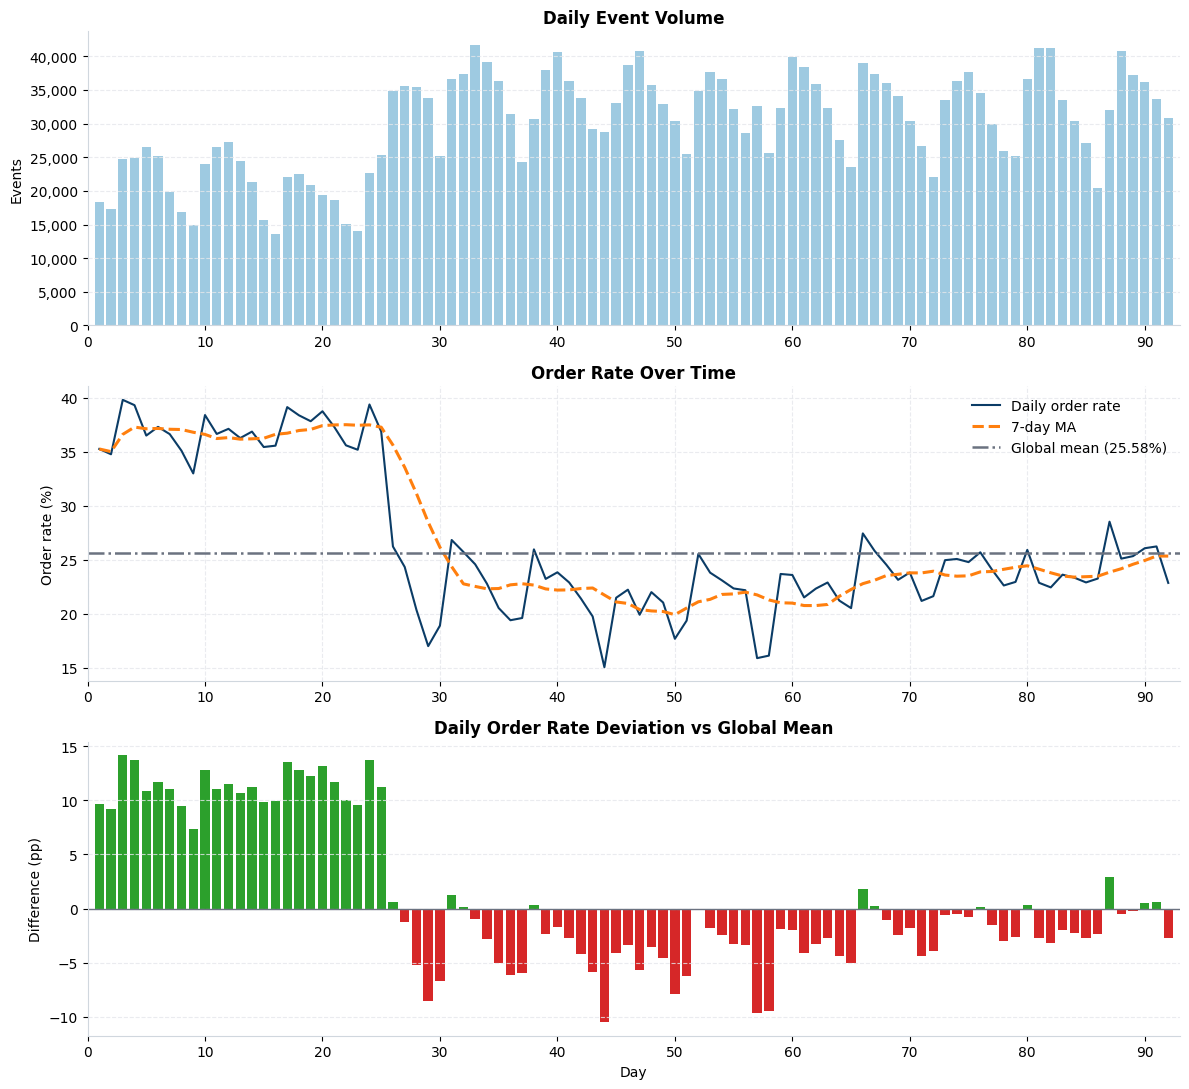

Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/day_analysis_7day_cycle_pattern.png


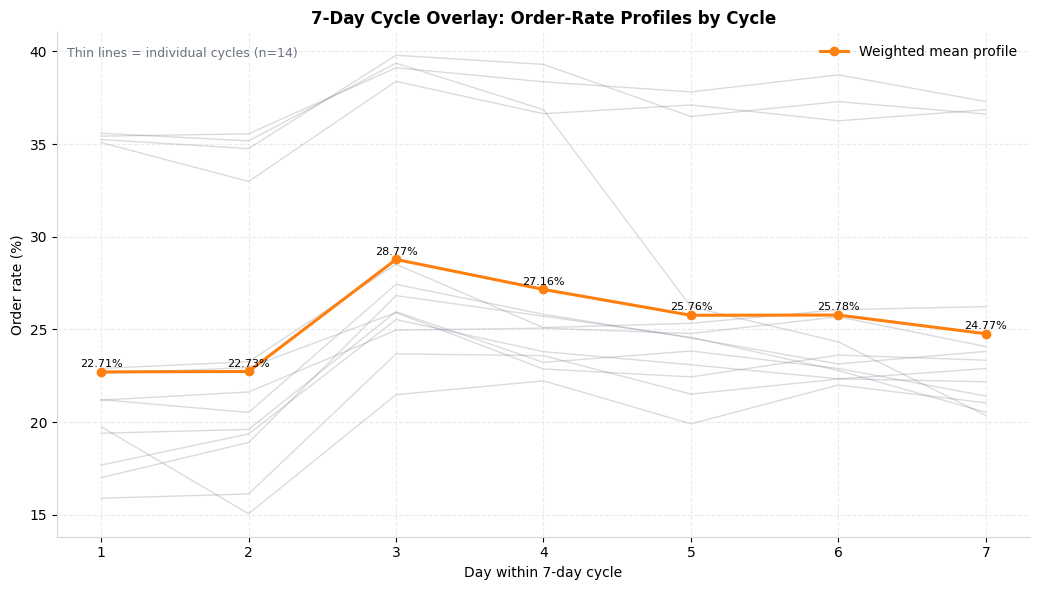

=== Day Analysis Data Integrity Checks ===
day_min: 1
day_max: 92
unique_days: 92
is_consecutive: True
missing_days: []

=== Day Analysis Summary ===
Days covered: 1 to 92 (92 days)
Total events: 2,756,003
Total orders: 705,090
Global order rate: 25.58%
Peak day: 3 | order rate=39.79% | events=24,669
Lowest day: 44 | order rate=15.06% | events=28,810

=== 7-Day Cycle Insight ===
Best cycle day: 3 | weighted order rate=28.77% | avg events/day=30944
Lowest cycle day: 1 | weighted order rate=22.71% | avg events/day=25818

=== Phase Summary ===
         regime  start_day  end_day  n_days  total_events  orders  weighted_order_rate
      pre_break          1       31      31        723274  238858                 0.33
transition_week         32       38       7        240927   55062                 0.23
     post_break         39       92      54       1791802  411170                 0.23


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Day Analysis From Scratch (project-focused)
# ============================================================

viz = globals().get(
    "VIZ_COLORS",
    {
        "primary": "#1f77b4",
        "primary_light": "#9ecae1",
        "primary_dark": "#0b3c66",
        "highlight": "#ff7f0e",
        "neutral": "#6b7280",
        "success": "#2ca02c",
        "danger": "#d62728",
        "grid": "#e5e7eb",
    },
)

# 1) Validation and setup
required_cols = {"day", "order"}
missing_cols = required_cols - set(train_raw_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in train_raw_df: {sorted(missing_cols)}")

PROCESSED_DIR = Path("data/processed")
FIGURES_DIR = Path("figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = train_raw_df.loc[:, ["day", "order"]].copy()

# Coerce day to numeric safely
df["day"] = pd.to_numeric(df["day"], errors="coerce")
if df["day"].isna().any():
    bad_rows = int(df["day"].isna().sum())
    raise ValueError(f"Column day contains {bad_rows} non-numeric values.")

# Optional strictness: day should be integer-like and positive
if not np.allclose(df["day"], np.floor(df["day"])):
    raise ValueError("Column day must be integer-like values.")
if (df["day"] <= 0).any():
    raise ValueError("Column day must be positive.")

df["day"] = df["day"].astype(int)

# Validate order is binary
order_values = set(df["order"].dropna().unique())
if not order_values.issubset({0, 1}):
    raise ValueError(f"Column order must be binary (0/1). Found: {sorted(order_values)}")

# 2) Daily aggregation
daily_stats = (
    df.groupby("day", as_index=False)
    .agg(
        total_events=("order", "size"),
        orders=("order", "sum"),
    )
    .sort_values("day")
)

daily_stats["order_rate"] = daily_stats["orders"] / daily_stats["total_events"]
daily_stats["non_orders"] = daily_stats["total_events"] - daily_stats["orders"]

# Rolling signals
daily_stats["order_rate_7d_ma"] = daily_stats["order_rate"].rolling(window=7, min_periods=1).mean()
daily_stats["order_rate_14d_ma"] = daily_stats["order_rate"].rolling(window=14, min_periods=1).mean()

# Global baseline
global_order_rate = df["order"].mean()
daily_stats["order_rate_vs_global_pp"] = (daily_stats["order_rate"] - global_order_rate) * 100

# 3) Structural change detection (simple and interpretable)
# Largest absolute 7-day MA shift over a 7-day lag
daily_stats["ma7_change_abs"] = (daily_stats["order_rate_7d_ma"] - daily_stats["order_rate_7d_ma"].shift(7)).abs()

if daily_stats["ma7_change_abs"].notna().any():
    break_idx = daily_stats["ma7_change_abs"].idxmax()
    break_day = int(daily_stats.loc[break_idx, "day"])
else:
    break_day = int(daily_stats["day"].min())

# Regime labeling: pre / transition week / post
daily_stats["regime"] = np.select(
    [
        daily_stats["day"] < break_day,
        daily_stats["day"].between(break_day, break_day + 6, inclusive="both"),
        daily_stats["day"] > break_day + 6,
    ],
    [
        "pre_break",
        "transition_week",
        "post_break",
    ],
    default="post_break",
)

regime_summary = (
    daily_stats.groupby("regime", as_index=False)
    .agg(
        start_day=("day", "min"),
        end_day=("day", "max"),
        n_days=("day", "count"),
        total_events=("total_events", "sum"),
        orders=("orders", "sum"),
    )
    .sort_values("start_day")
)
regime_summary["weighted_order_rate"] = regime_summary["orders"] / regime_summary["total_events"]

# 4) Top/bottom day table
top_days = daily_stats.nlargest(5, "order_rate").copy()
top_days["extreme_type"] = "top_5_rate"

bottom_days = daily_stats.nsmallest(5, "order_rate").copy()
bottom_days["extreme_type"] = "bottom_5_rate"

extreme_days = pd.concat([top_days, bottom_days], ignore_index=True).sort_values(
    ["extreme_type", "order_rate"], ascending=[True, False]
)

# 5) Persist output tables
daily_stats.to_csv(PROCESSED_DIR / "day_analysis_daily_stats.csv", index=False)
regime_summary.to_csv(PROCESSED_DIR / "day_analysis_regime_summary.csv", index=False)
extreme_days.to_csv(PROCESSED_DIR / "day_analysis_extreme_days.csv", index=False)

# 6) Plot overview (3 panels)
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

# Panel A: Daily volume
axes[0].bar(daily_stats["day"], daily_stats["total_events"], color=viz["primary_light"], edgecolor="none")
axes[0].set_title("Daily Event Volume")
axes[0].set_ylabel("Events")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))

# Panel B: Daily order rate with MA + global mean
global_mean_pct = global_order_rate * 100

axes[1].plot(
    daily_stats["day"],
    daily_stats["order_rate"] * 100,
    color=viz["primary_dark"],
    linewidth=1.5,
    label="Daily order rate",
)
axes[1].plot(
    daily_stats["day"],
    daily_stats["order_rate_7d_ma"] * 100,
    color=viz["highlight"],
    linewidth=2.2,
    linestyle="--",
    label="7-day MA",
)

# Global mean reference line
axes[1].axhline(
    global_mean_pct,
    color=viz["neutral"],
    linestyle="-.",
    linewidth=1.8,
    label=f"Global mean ({global_mean_pct:.2f}%)",
)

axes[1].set_title("Order Rate Over Time")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="both", alpha=0.8, color=viz["grid"])
axes[1].legend(loc="best")

# Panel C: Deviation from global baseline
colors = np.where(daily_stats["order_rate_vs_global_pp"] >= 0, viz["success"], viz["danger"])
axes[2].bar(daily_stats["day"], daily_stats["order_rate_vs_global_pp"], color=colors, edgecolor="none")
axes[2].axhline(0, color=viz["neutral"], linewidth=1)
axes[2].set_title("Daily Order Rate Deviation vs Global Mean")
axes[2].set_xlabel("Day")
axes[2].set_ylabel("Difference (pp)")
axes[2].grid(axis="y", alpha=0.8, color=viz["grid"])

x_max = int(daily_stats["day"].max())

# 0, 10, 20, ... 90 (leave out 92)
xticks = list(range(0, x_max, 10))

for ax in axes:
    ax.set_xlim(0, 93)
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelbottom=True)

fig.tight_layout()
fig_path = FIGURES_DIR / "day_analysis_overview.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig_path.resolve()}")
plt.show()
plt.close(fig)

# 7) 7-day cycle pattern (all cycles overlapped)
cycle_overlay = daily_stats.loc[:, ["day", "total_events", "orders", "order_rate"]].copy()
cycle_overlay["cycle_id"] = ((cycle_overlay["day"] - 1) // 7) + 1
cycle_overlay["day_in_cycle"] = ((cycle_overlay["day"] - 1) % 7) + 1

weekly_pattern = (
    cycle_overlay.groupby("day_in_cycle", as_index=False)
    .agg(
        n_days=("day", "count"),
        total_events=("total_events", "sum"),
        total_orders=("orders", "sum"),
        avg_daily_events=("total_events", "mean"),
        avg_daily_order_rate=("order_rate", "mean"),
        n_cycles_with_data=("cycle_id", "nunique"),
    )
    .sort_values("day_in_cycle")
)
weekly_pattern["weighted_order_rate"] = weekly_pattern["total_orders"] / weekly_pattern["total_events"]
weekly_pattern.to_csv(PROCESSED_DIR / "day_analysis_7day_cycle_summary.csv", index=False)

fig2, ax2 = plt.subplots(figsize=(10.5, 6))

# Thin lines: each 7-day block as its own profile
for _, cycle_df in cycle_overlay.groupby("cycle_id"):
    cycle_df = cycle_df.sort_values("day_in_cycle")
    ax2.plot(
        cycle_df["day_in_cycle"],
        cycle_df["order_rate"] * 100,
        color=viz["neutral"],
        linewidth=1.0,
        alpha=0.25,
    )

# Bold line: weighted mean profile across all cycles
x = weekly_pattern["day_in_cycle"].to_numpy()
rate_pct = weekly_pattern["weighted_order_rate"].to_numpy() * 100
ax2.plot(
    x,
    rate_pct,
    color=viz["highlight"],
    marker="o",
    linewidth=2.2,
    label="Weighted mean profile",
)

for x_val, pct in zip(x, rate_pct):
    ax2.text(x_val, pct + 0.15, f"{pct:.2f}%", ha="center", va="bottom", fontsize=8)

ax2.set_title("7-Day Cycle Overlay: Order-Rate Profiles by Cycle")
ax2.set_xlabel("Day within 7-day cycle")
ax2.set_ylabel("Order rate (%)")
ax2.set_xticks(range(1, 8))
ax2.grid(axis="both", alpha=0.8, color=viz["grid"])
ax2.legend(loc="upper right")
ax2.text(
    0.01,
    0.97,
    f"Thin lines = individual cycles (n={int(cycle_overlay['cycle_id'].nunique())})",
    transform=ax2.transAxes,
    va="top",
    fontsize=9,
    color=viz["neutral"],
)

fig2.tight_layout()
fig2_path = FIGURES_DIR / "day_analysis_7day_cycle_pattern.png"
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig2_path.resolve()}")
plt.show()
plt.close(fig2)

best_cycle = weekly_pattern.loc[weekly_pattern["weighted_order_rate"].idxmax()]
worst_cycle = weekly_pattern.loc[weekly_pattern["weighted_order_rate"].idxmin()]

# 8) Console summary for direct report writing
peak_row = daily_stats.loc[daily_stats["order_rate"].idxmax()]
trough_row = daily_stats.loc[daily_stats["order_rate"].idxmin()]

day_min = int(train_raw_df["day"].min())
day_max = int(train_raw_df["day"].max())
n_unique_days = int(train_raw_df["day"].nunique())

expected_days = set(range(day_min, day_max + 1))
observed_days = set(train_raw_df["day"].unique())
missing_days = sorted(expected_days - observed_days)

print("=== Day Analysis Data Integrity Checks ===")
print("day_min:", day_min)
print("day_max:", day_max)
print("unique_days:", n_unique_days)
print("is_consecutive:", len(missing_days) == 0)
print("missing_days:", missing_days[:10])

print("\n=== Day Analysis Summary ===")
print(f"Days covered: {daily_stats['day'].min()} to {daily_stats['day'].max()} ({len(daily_stats)} days)")
print(f"Total events: {int(daily_stats['total_events'].sum()):,}")
print(f"Total orders: {int(daily_stats['orders'].sum()):,}")
print(f"Global order rate: {global_order_rate * 100:.2f}%")
print(f"Peak day: {int(peak_row['day'])} | order rate={peak_row['order_rate'] * 100:.2f}% | events={int(peak_row['total_events']):,}")
print(f"Lowest day: {int(trough_row['day'])} | order rate={trough_row['order_rate'] * 100:.2f}% | events={int(trough_row['total_events']):,}")
print("\n=== 7-Day Cycle Insight ===")
print(
    f"Best cycle day: {int(best_cycle['day_in_cycle'])} | weighted order rate={best_cycle['weighted_order_rate'] * 100:.2f}% | avg events/day={best_cycle['avg_daily_events']:.0f}"
)
print(
    f"Lowest cycle day: {int(worst_cycle['day_in_cycle'])} | weighted order rate={worst_cycle['weighted_order_rate'] * 100:.2f}% | avg events/day={worst_cycle['avg_daily_events']:.0f}"
)
print("\n=== Phase Summary ===")
print(regime_summary.to_string(index=False))

**Notes**:
- We see two phases with one break of 7 days in between
- We see a negative correlation of order rate and event volume
    - Phase 1: Lower event count, higher order rate
    - Phase 2: Higher event count,  lower order rate
    - Conclusion: **More events does *not* bring more sales**

**Exploration of Price & Competition (price, rrp, competitorPrice)**

***Price***

In [17]:
import pandas as pd
from pathlib import Path

# Build from train.csv (or already loaded train_raw_df)
if "train_raw_df" in globals():
    price_source = train_raw_df.copy()
else:
    price_source = pd.read_csv(Path("data/train.csv"), sep="|")

required_cols = {"pid", "price"}
missing = sorted(required_cols - set(price_source.columns))
if missing:
    raise ValueError(f"Missing required columns in train data: {missing}")

# Sort by lineID if available (fallback to row order proxy if not present)
lineid_candidates = [c for c in ["lineID", "lineId", "line_id"] if c in price_source.columns]
if lineid_candidates:
    line_id_col = lineid_candidates[0]
else:
    line_id_col = "_row_order_proxy"
    price_source[line_id_col] = range(1, len(price_source) + 1)
    print("lineID not found; used row-order proxy for sorting.")

price_source["price"] = pd.to_numeric(price_source["price"], errors="coerce")

sorted_prices = (
    price_source.loc[:, [line_id_col, "pid", "price"]]
    .dropna(subset=["pid"])
    .sort_values(line_id_col)
)

# Create wide table with one column per pid and lineID-sorted price values
sorted_prices["row_idx"] = sorted_prices.groupby("pid", sort=True).cumcount()
pid_price_table = sorted_prices.pivot(index="row_idx", columns="pid", values="price")

# Stable column ordering by pid
try:
    sorted_cols = sorted(pid_price_table.columns, key=lambda x: float(x))
except Exception:
    sorted_cols = sorted(pid_price_table.columns, key=lambda x: str(x))
pid_price_table = pid_price_table.reindex(columns=sorted_cols)

# Save table without lineID column included
PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "pid_columns_price_values_sorted_by_lineid.csv"
pid_price_table.to_csv(out_path, index=False)

print("Created table with one column per pid and price values sorted by lineID.")
print(f"Output path: {out_path.resolve()}")
print(f"Table shape: {pid_price_table.shape[0]:,} rows x {pid_price_table.shape[1]:,} pid columns")
pid_price_table.head()

RRP check for pid 2: 10.89
Created table with one column per pid and price values sorted by lineID.
Output path: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/pid_columns_price_values_sorted_by_lineid.csv
Table shape: 53,785 rows x 21,928 pid columns


pid,1,2,3,4,5,6,7,8,9,10,...,22026,22027,22028,22029,22030,22031,22032,22033,22034,22035
row_idx,,,,,,,,,,,,,,,,,,,,,
0,10.08,10.08,15.21,10.08,14.72,8.98,15.20,10.08,9.11,16.45,...,2.04,9.05,7.27,15.16,17.44,12.41,4.85,6.01,24.74,40.01
1,10.08,8.42,15.21,9.89,14.72,8.24,15.64,10.08,9.11,16.45,...,2.04,9.05,7.27,15.16,20.26,12.41,4.85,6.11,24.74,44.36
2,7.28,10.08,15.21,10.08,15.00,9.11,15.64,10.08,7.65,16.45,...,2.04,9.05,7.27,15.16,20.30,12.75,5.04,6.11,25.43,38.21
3,7.28,NaN,15.21,10.08,15.27,7.12,19.56,10.08,9.11,16.45,...,2.04,9.05,7.27,15.16,20.30,NaN,5.04,NaN,25.43,40.14
4,8.42,NaN,15.21,10.08,18.79,6.42,16.76,9.93,8.87,16.45,...,2.04,9.05,7.27,15.16,16.18,NaN,4.95,NaN,25.43,44.36


In [16]:
# Short check: what is the rrp of pid 2?
if "items_raw_df" in globals():
    items_source = items_raw_df.copy()
else:
    items_source = pd.read_csv(Path("data/items.csv"), sep="|")

pid_2_rrp_values = pd.to_numeric(
    items_source.loc[items_source["pid"] == 2, "rrp"],
    errors="coerce",
).dropna().unique()

if len(pid_2_rrp_values) == 0:
    print("RRP check for pid 2: no value found.")
elif len(pid_2_rrp_values) == 1:
    print(f"RRP check for pid 2: {pid_2_rrp_values[0]:.2f}")
else:
    print(f"RRP check for pid 2: multiple values found {sorted(pid_2_rrp_values.tolist())}")

RRP check for pid 2: 10.89


Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/price_distribution_all.png


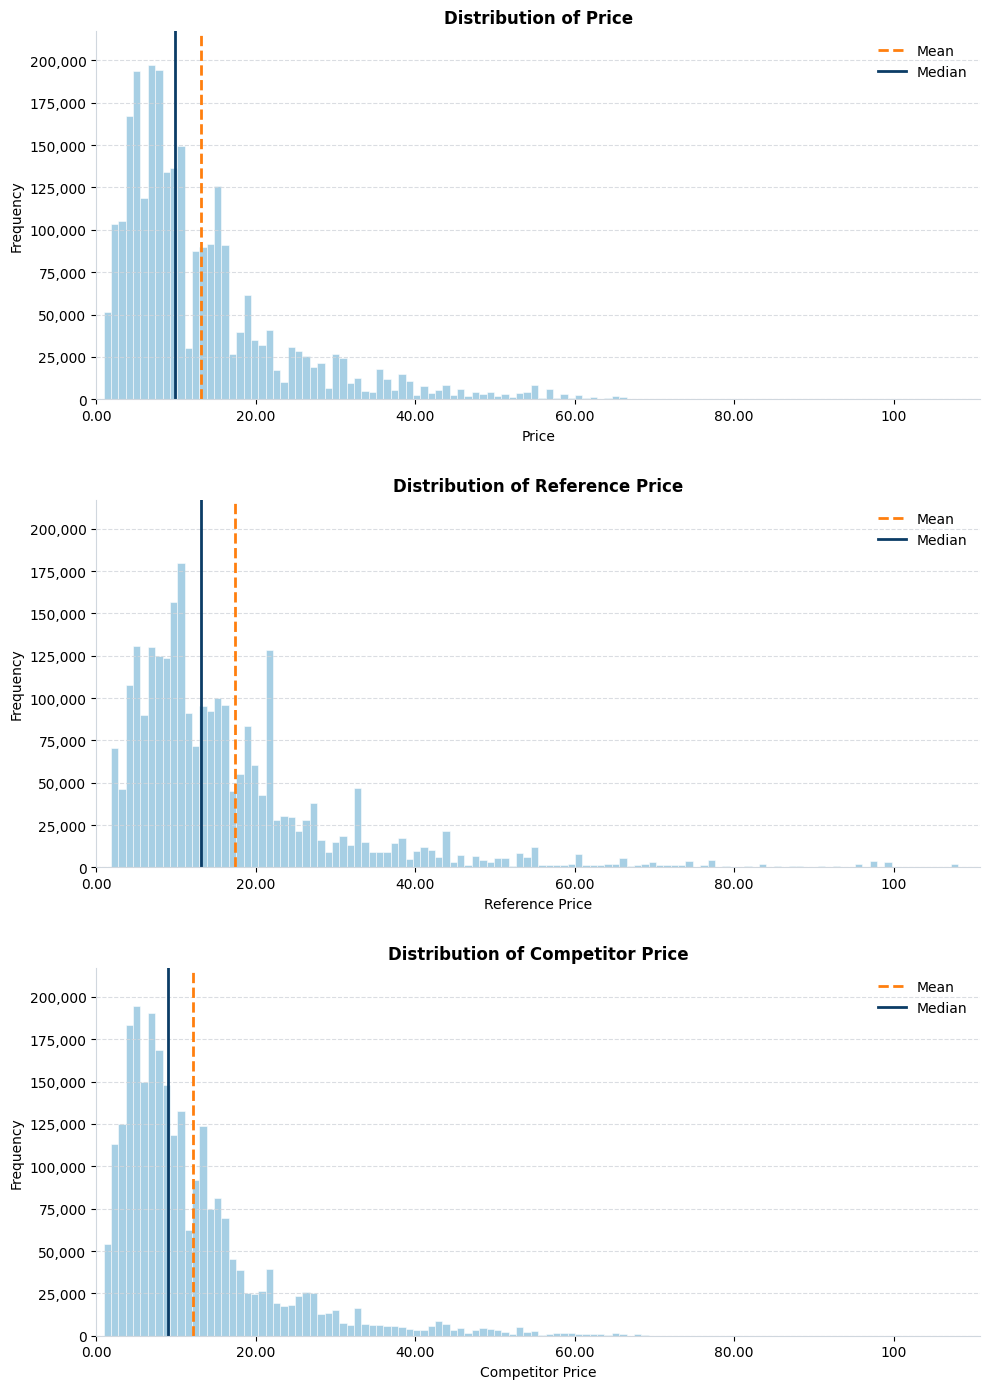

Saved artifacts:
/Users/annageiser/Documents/GitHub/analytics-project/data/processed/price_attr_quality.csv
/Users/annageiser/Documents/GitHub/analytics-project/data/processed/price_attr_distribution_summary.csv
/Users/annageiser/Documents/GitHub/analytics-project/figures/price_distribution_all.png


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Expert Distribution Analysis: price, rrp, competitorPrice
# ============================================================

viz = globals().get(
    "VIZ_COLORS",
    {
        "primary": "#1f77b4",
        "primary_light": "#9ecae1",
        "primary_dark": "#0b3c66",
        "highlight": "#ff7f0e",
        "neutral_light": "#d1d5db",
    },
)

ATTRIBUTES = ["price", "rrp", "competitorPrice"]
LOW_Q = 0.01
HIGH_Q = 0.99

# 1) Build analysis dataset
if "train_item_set" in globals():
    analysis_df = train_item_set.copy()
else:
    train_df = pd.read_csv(Path("data/train.csv"), sep="|")
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")
    analysis_df = train_df.merge(items_df, on="pid", how="left", validate="m:1")

missing_required = [c for c in ATTRIBUTES if c not in analysis_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Keep only relevant columns and coerce to numeric
work = analysis_df.loc[:, ATTRIBUTES].copy()
for c in ATTRIBUTES:
    work[c] = pd.to_numeric(work[c], errors="coerce")


def fd_bin_count(values: np.ndarray, min_bins: int = 30, max_bins: int = 120) -> int:
    x = values[np.isfinite(values)]
    n = x.size
    if n < 2:
        return min_bins
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        return min_bins
    bin_width = 2 * iqr / np.cbrt(n)
    if bin_width <= 0:
        return min_bins
    bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return int(np.clip(bins, min_bins, max_bins))


# 2) Data quality and summary tables (kept for reproducibility)
quality_rows = []
summary_rows = []

for c in ATTRIBUTES:
    s = work[c].dropna()
    n_non_missing = int(s.shape[0])
    n_missing = int(work[c].isna().sum())
    n_non_positive = int((s <= 0).sum())

    p01 = float(s.quantile(LOW_Q)) if n_non_missing else np.nan
    p50 = float(s.quantile(0.50)) if n_non_missing else np.nan
    p90 = float(s.quantile(0.90)) if n_non_missing else np.nan
    p95 = float(s.quantile(0.95)) if n_non_missing else np.nan
    p99 = float(s.quantile(HIGH_Q)) if n_non_missing else np.nan

    tail_share = float((s > p99).mean() * 100) if n_non_missing else np.nan
    central = s[(s >= p01) & (s <= p99)] if n_non_missing else s

    quality_rows.append(
        {
            "attribute": c,
            "n_total": int(len(work)),
            "n_missing": n_missing,
            "missing_pct": round(n_missing / len(work) * 100, 4),
            "n_non_positive": n_non_positive,
            "non_positive_pct": round((n_non_positive / n_non_missing * 100) if n_non_missing else np.nan, 4),
            "n_central_p1_p99": int(central.shape[0]),
            "tail_gt_p99_pct": round(tail_share, 4),
        }
    )

    summary_rows.append(
        {
            "attribute": c,
            "count_non_null": n_non_missing,
            "mean": float(s.mean()) if n_non_missing else np.nan,
            "std": float(s.std()) if n_non_missing else np.nan,
            "min": float(s.min()) if n_non_missing else np.nan,
            "p01": p01,
            "q25": float(s.quantile(0.25)) if n_non_missing else np.nan,
            "median": p50,
            "q75": float(s.quantile(0.75)) if n_non_missing else np.nan,
            "p90": p90,
            "p95": p95,
            "p99": p99,
            "max": float(s.max()) if n_non_missing else np.nan,
            "skewness": float(s.skew()) if n_non_missing else np.nan,
        }
    )

quality_tbl = pd.DataFrame(quality_rows)
summary_tbl = pd.DataFrame(summary_rows)

# 3) Persist outputs
PROCESSED_DIR = Path("data/processed")
FIGURES_DIR = Path("figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

quality_tbl.to_csv(PROCESSED_DIR / "price_attr_quality.csv", index=False)
summary_tbl.to_csv(PROCESSED_DIR / "price_attr_distribution_summary.csv", index=False)

# 4) One combined figure with three stacked distributions
title_map = {
    "price": "Distribution of Price",
    "rrp": "Distribution of Reference Price",
    "competitorPrice": "Distribution of Competitor Price",
}

x_label_map = {
    "price": "Price",
    "rrp": "Reference Price",
    "competitorPrice": "Competitor Price",
}


def readable_x(v, _):
    if abs(v) >= 100:
        return f"{v:,.0f}"
    return f"{v:,.2f}"


plot_specs = []
for c in ATTRIBUTES:
    s = work[c].dropna()
    p01 = float(s.quantile(LOW_Q))
    p99 = float(s.quantile(HIGH_Q))
    plot_s = s[(s >= p01) & (s <= p99)]

    plot_specs.append(
        {
            "attribute": c,
            "series": plot_s,
            "mean": float(plot_s.mean()),
            "median": float(plot_s.median()),
        }
    )

# Keep one common x-axis range across all three plots
x_candidates = [float(spec["series"].max()) for spec in plot_specs if not spec["series"].empty]
global_xmax = max(x_candidates) if x_candidates else 1.0
if not np.isfinite(global_xmax) or global_xmax <= 0:
    global_xmax = 1.0
x_limit = global_xmax * 1.02

# Keep one common bin width (same bin edges) across all three plots
combined_values = np.concatenate([spec["series"].to_numpy() for spec in plot_specs if not spec["series"].empty])
common_bins = fd_bin_count(combined_values, min_bins=30, max_bins=120) if combined_values.size else 30
common_bins = max(common_bins, 1)
common_bin_edges = np.linspace(0, x_limit, common_bins + 1)

# Keep one common y-axis scale across all three plots
global_ymax = 0
for spec in plot_specs:
    counts, _ = np.histogram(spec["series"], bins=common_bin_edges)
    if counts.size:
        global_ymax = max(global_ymax, int(counts.max()))
if global_ymax <= 0:
    global_ymax = 1
y_limit = global_ymax * 1.10

fig, axes = plt.subplots(len(ATTRIBUTES), 1, figsize=(10, 14), sharey=True, sharex=True)
fig.patch.set_facecolor("white")

if len(ATTRIBUTES) == 1:
    axes = [axes]

for ax, spec in zip(axes, plot_specs):
    c = spec["attribute"]
    plot_s = spec["series"]

    ax.set_facecolor("white")
    ax.hist(
        plot_s,
        bins=common_bin_edges,
        color=viz["primary_light"],
        alpha=0.9,
        edgecolor="white",
        linewidth=0.4,
    )

    ax.axvline(spec["mean"], color=viz["highlight"], linestyle="--", linewidth=2, label="Mean")
    ax.axvline(spec["median"], color=viz["primary_dark"], linestyle="-", linewidth=2, label="Median")

    ax.set_title(title_map[c])
    ax.set_xlabel(x_label_map[c])
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, x_limit)
    ax.set_ylim(0, y_limit)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.8, color=viz["neutral_light"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.xaxis.set_major_formatter(FuncFormatter(readable_x))
    ax.tick_params(axis="x", labelbottom=True)

    ax.legend(loc="upper right")

fig.tight_layout(h_pad=2.5)
combined_path = FIGURES_DIR / "price_distribution_all.png"
fig.savefig(combined_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {combined_path.resolve()}")
plt.show()
plt.close(fig)

# 5) Minimal console output
print("Saved artifacts:")
print((PROCESSED_DIR / "price_attr_quality.csv").resolve())
print((PROCESSED_DIR / "price_attr_distribution_summary.csv").resolve())
print(combined_path.resolve())

**Explore marketing & availability**

***adFlag***

=== adFlag Distribution ===
adFlag     count share_pct
     0 1,880,176    68.22%
     1   875,827    31.78%

=== adFlag Order Rate ===
adFlag total_events  orders order_rate_pct
     0    1,880,176 422,727         22.48%
     1      875,827 282,363         32.24%

Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/adflag_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/adflag_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/adflag_order_rate.csv


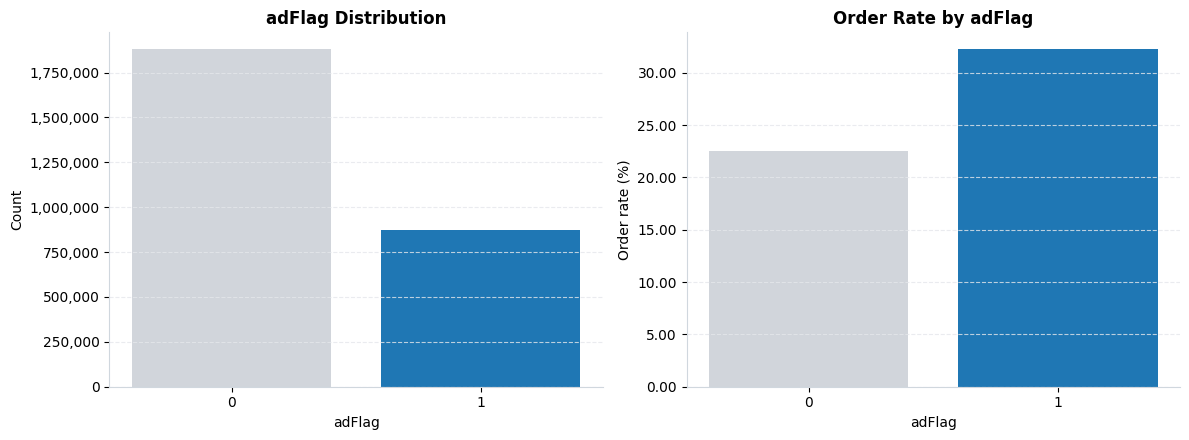

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: adFlag (distribution + order rate)
# ============================================================

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

if "train_raw_df" in globals():
    ad_source = train_raw_df.copy()
else:
    ad_source = pd.read_csv(Path("data/train.csv"), sep="|")

required_cols = {"adFlag", "order"}
missing_cols = sorted(required_cols - set(ad_source.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for adFlag analysis: {missing_cols}")

work = ad_source.loc[:, ["adFlag", "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce")

# Keep missing adFlag visible in distribution and order-rate output
display_adflag = work["adFlag"].astype("string").fillna("missing")

# 1) Distribution
dist_counts = display_adflag.value_counts(dropna=False).sort_index()
dist_tbl = (
    dist_counts.rename_axis("adFlag")
    .reset_index(name="count")
    .assign(share_pct=lambda d: (d["count"] / d["count"].sum() * 100).round(2))
)

dist_print = dist_tbl.copy()
dist_print["count"] = dist_print["count"].map(lambda x: f"{int(x):,}")
dist_print["share_pct"] = dist_print["share_pct"].map(lambda x: f"{x:.2f}%")

print("=== adFlag Distribution ===")
print(dist_print.to_string(index=False))

# 2) Order rate by adFlag
order_rate_tbl = (
    pd.DataFrame({"adFlag": display_adflag, "order": work["order"]})
    .groupby("adFlag", as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
order_rate_tbl = order_rate_tbl.sort_values("adFlag")

order_print = order_rate_tbl[["adFlag", "total_events", "orders", "order_rate_pct"]].copy()
order_print["total_events"] = order_print["total_events"].map(lambda x: f"{int(x):,}")
order_print["orders"] = order_print["orders"].map(lambda x: f"{int(x):,}")
order_print["order_rate_pct"] = order_print["order_rate_pct"].map(lambda x: f"{x:.2f}%")

print("\n=== adFlag Order Rate ===")
print(order_print.to_string(index=False))

# Persist tables
PROCESSED_DIR = Path("data/processed")
FIGURES_DIR = Path("figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dist_out = PROCESSED_DIR / "adflag_distribution.csv"
order_rate_out = PROCESSED_DIR / "adflag_order_rate.csv"
dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)

# Plot distribution + order rate with the same class-color logic used in order analysis
class_colors = {
    "0": viz["neutral_light"],
    "1": viz["primary"],
}

dist_color_keys = dist_tbl["adFlag"].astype(str)
order_color_keys = order_rate_tbl["adFlag"].astype(str)

dist_bar_colors = [class_colors.get(k, viz["neutral_light"]) for k in dist_color_keys]
order_bar_colors = [class_colors.get(k, viz["neutral_light"]) for k in order_color_keys]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    dist_tbl["adFlag"].astype(str),
    dist_tbl["count"],
    color=dist_bar_colors,
)
axes[0].set_title("adFlag Distribution")
axes[0].set_xlabel("adFlag")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(
    order_rate_tbl["adFlag"].astype(str),
    order_rate_tbl["order_rate_pct"],
    color=order_bar_colors,
)
axes[1].set_title("Order Rate by adFlag")
axes[1].set_xlabel("adFlag")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[1].tick_params(axis="x", rotation=0)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = FIGURES_DIR / "adflag_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"\nSaved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")

plt.show()
plt.close(fig)

***availability***

items.csv availability distribution: availability column not found
=== availability Distribution ===
availability     count share_pct
           1 2,515,572    91.28%
           2   185,194     6.72%
           3    44,893     1.63%
           4    10,344     0.38%

=== availability Order Rate ===
availability total_events  orders order_rate_pct
           1    2,515,572 673,456         26.77%
           2      185,194  26,980         14.57%
           3       44,893   4,651         10.36%
           4       10,344       3          0.03%

Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/availability_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/availability_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/availability_order_rate.csv


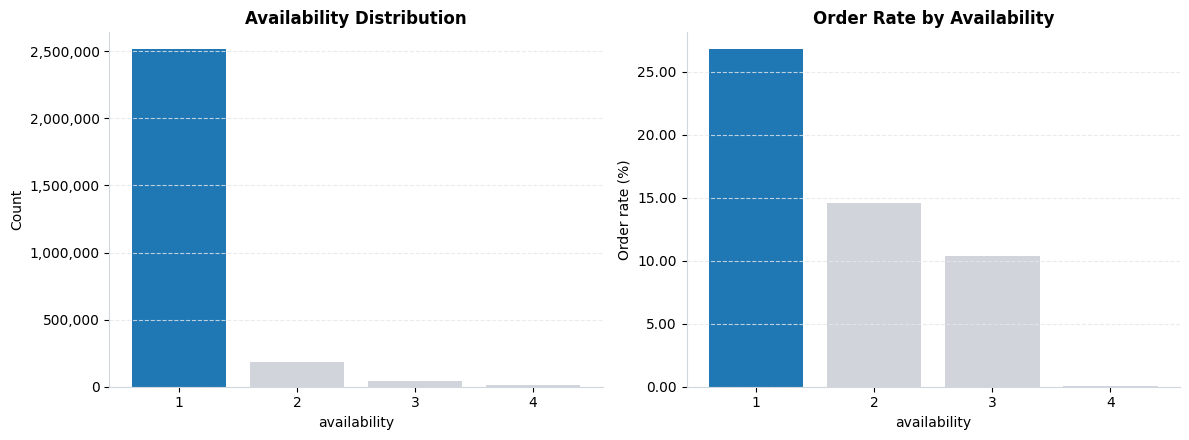

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

ATTR = "availability"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

print(
    "items.csv availability distribution:",
    items_df[ATTR].value_counts(dropna=False).sort_index().to_dict()
    if ATTR in items_df.columns
    else f"{ATTR} column not found",
)

required_cols = {ATTR, "order"}
missing_cols = sorted(required_cols - set(src_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {ATTR} analysis: {missing_cols}")

work = src_df.loc[:, [ATTR, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce")
work[ATTR] = work[ATTR].astype("string").fillna("missing")

dist_tbl = (
    work[ATTR]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(ATTR)
    .reset_index(name="count")
)
dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

order_rate_tbl = (
    work.groupby(ATTR, as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
    .sort_values(ATTR)
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

dist_print = dist_tbl.copy()
dist_print["count"] = dist_print["count"].map(lambda x: f"{int(x):,}")
dist_print["share_pct"] = dist_print["share_pct"].map(lambda x: f"{x:.2f}%")

order_print = order_rate_tbl[[ATTR, "total_events", "orders", "order_rate_pct"]].copy()
order_print["total_events"] = order_print["total_events"].map(lambda x: f"{int(x):,}")
order_print["orders"] = order_print["orders"].map(lambda x: f"{int(x):,}")
order_print["order_rate_pct"] = order_print["order_rate_pct"].map(lambda x: f"{x:.2f}%")

print(f"=== {ATTR} Distribution ===")
print(dist_print.to_string(index=False))
print(f"\n=== {ATTR} Order Rate ===")
print(order_print.to_string(index=False))

processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "availability_distribution.csv"
order_rate_out = processed_dir / "availability_order_rate.csv"
fig_out = figures_dir / "availability_distribution_order_rate.png"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)

class_colors = {"0": viz["neutral_light"], "1": viz["primary"]}
dist_colors = [class_colors.get(x, viz["neutral_light"]) for x in dist_tbl[ATTR].astype(str)]
rate_colors = [class_colors.get(x, viz["neutral_light"]) for x in order_rate_tbl[ATTR].astype(str)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(dist_tbl[ATTR].astype(str), dist_tbl["count"], color=dist_colors)
axes[0].set_title("Availability Distribution")
axes[0].set_xlabel("availability")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(order_rate_tbl[ATTR].astype(str), order_rate_tbl["order_rate_pct"], color=rate_colors)
axes[1].set_title("Order Rate by Availability")
axes[1].set_xlabel("availability")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(fig_out, dpi=300, bbox_inches="tight")
print(f"\nSaved figure to: {fig_out.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")

plt.show()
plt.close(fig)

items.csv campaignIndex distribution: {'A': 350, 'B': 738, 'C': 250, nan: 20697}
=== campaignIndex Distribution ===
campaignIndex     count share_pct
            A   144,010     5.23%
            B   251,965     9.14%
            C    72,060     2.61%
      missing 2,287,968    83.02%

=== campaignIndex Order Rate ===
campaignIndex total_events  orders order_rate_pct
            A      144,010  45,409         31.53%
            B      251,965  64,136         25.45%
            C       72,060  18,922         26.26%
      missing    2,287,968 576,623         25.20%

Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/campaignindex_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/campaignindex_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/campaignindex_order_rate.csv


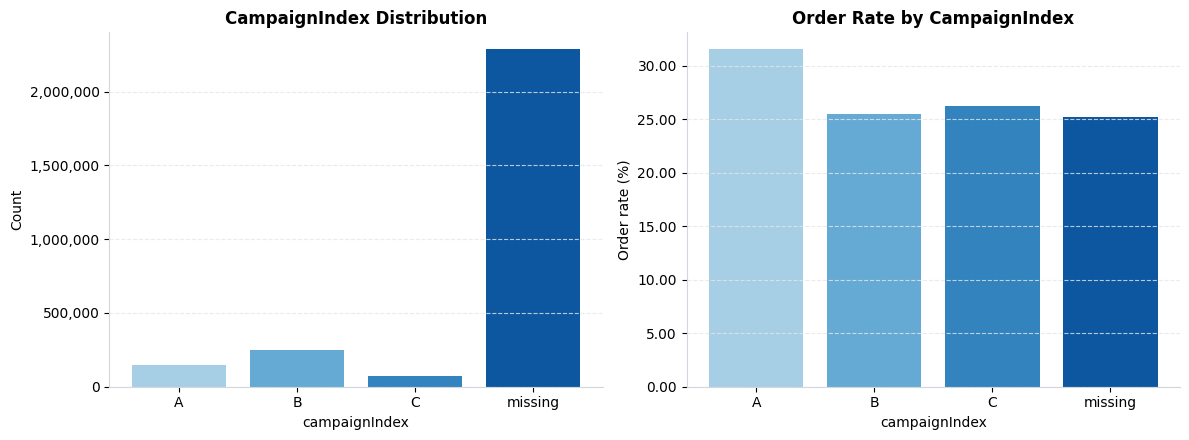

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Same analysis pattern as availability/adFlag
attr_candidates = ["campaignIndex", "campaignindex"]

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

print(
    "items.csv campaignIndex distribution:",
    items_df[items_attr].value_counts(dropna=False).sort_index().to_dict(),
)

# Bring campaignIndex to event-level train rows if it is not already present there
if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge campaignIndex: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce")
work[attr] = work[attr].astype("string").fillna("missing")

# 1) Distribution
dist_tbl = (
    work[attr]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(attr)
    .reset_index(name="count")
)
dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

# 2) Order rate
order_rate_tbl = (
    work.groupby(attr, as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
    .sort_values(attr)
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

# Pretty print without scientific format
dist_print = dist_tbl.copy()
dist_print["count"] = dist_print["count"].map(lambda x: f"{int(x):,}")
dist_print["share_pct"] = dist_print["share_pct"].map(lambda x: f"{x:.2f}%")

order_print = order_rate_tbl[[attr, "total_events", "orders", "order_rate_pct"]].copy()
order_print["total_events"] = order_print["total_events"].map(lambda x: f"{int(x):,}")
order_print["orders"] = order_print["orders"].map(lambda x: f"{int(x):,}")
order_print["order_rate_pct"] = order_print["order_rate_pct"].map(lambda x: f"{x:.2f}%")

print(f"=== {attr} Distribution ===")
print(dist_print.to_string(index=False))
print(f"\n=== {attr} Order Rate ===")
print(order_print.to_string(index=False))

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "campaignindex_distribution.csv"
order_rate_out = processed_dir / "campaignindex_order_rate.csv"
fig_out = figures_dir / "campaignindex_distribution_order_rate.png"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)

# Assign a distinct blue tone to every category bar.
all_levels = sorted(set(dist_tbl[attr].astype(str)).union(set(order_rate_tbl[attr].astype(str))))
if len(all_levels) == 1:
    tone_values = [viz["primary"]]
elif len(all_levels) == 2:
    tone_values = [viz["primary_light"], viz["primary_dark"]]
else:
    tone_positions = [0.35 + (0.50 * i / (len(all_levels) - 1)) for i in range(len(all_levels))]
    tone_values = [plt.cm.Blues(pos) for pos in tone_positions]

tone_map = {level: tone for level, tone in zip(all_levels, tone_values)}
dist_colors = [tone_map[x] for x in dist_tbl[attr].astype(str)]
rate_colors = [tone_map[x] for x in order_rate_tbl[attr].astype(str)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(dist_tbl[attr].astype(str), dist_tbl["count"], color=dist_colors)
axes[0].set_title("CampaignIndex Distribution")
axes[0].set_xlabel(attr)
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(order_rate_tbl[attr].astype(str), order_rate_tbl["order_rate_pct"], color=rate_colors)
axes[1].set_title("Order Rate by CampaignIndex")
axes[1].set_xlabel(attr)
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(fig_out, dpi=300, bbox_inches="tight")
print(f"\nSaved figure to: {fig_out.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")

plt.show()
plt.close(fig)

**Explore product attributes**

***genericProduct***

items.csv genericProduct distribution: {0: 21293, 1: 742}
=== genericProduct Distribution ===
genericProduct     count share_pct
             0 2,465,221    89.45%
             1   290,782    10.55%

=== genericProduct Order Rate ===
genericProduct total_events  orders order_rate_pct
             0    2,465,221 595,818         24.17%
             1      290,782 109,272         37.58%

Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/genericproduct_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/genericproduct_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/genericproduct_order_rate.csv


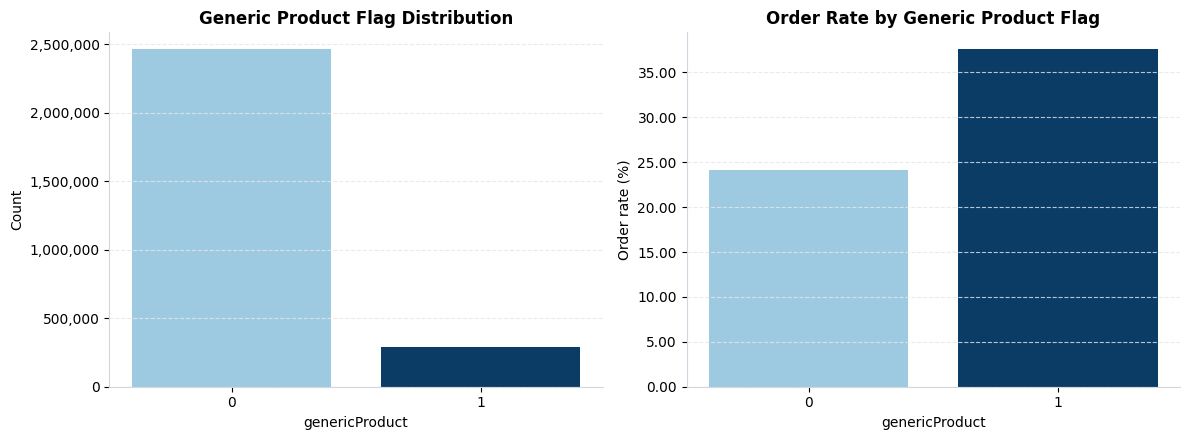

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

ATTR = "genericProduct"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

print(
    "items.csv genericProduct distribution:",
    items_df[ATTR].value_counts(dropna=False).sort_index().to_dict()
    if ATTR in items_df.columns
    else f"{ATTR} column not found",
)

if ATTR in src_df.columns:
    work_df = src_df.loc[:, [ATTR, "order"]].copy()
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge genericProduct: pid column is missing in train data.")
    if ATTR not in items_df.columns:
        raise ValueError("Cannot merge genericProduct: attribute not found in items data.")
    work_df = src_df.merge(items_df[["pid", ATTR]], on="pid", how="left", validate="m:1")
    work_df = work_df.loc[:, [ATTR, "order"]].copy()

work_df["order"] = pd.to_numeric(work_df["order"], errors="coerce")
work_df[ATTR] = work_df[ATTR].astype("string").fillna("missing")

dist_tbl = (
    work_df[ATTR]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(ATTR)
    .reset_index(name="count")
)
dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

order_rate_tbl = (
    work_df.groupby(ATTR, as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
    .sort_values(ATTR)
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

dist_print = dist_tbl.copy()
dist_print["count"] = dist_print["count"].map(lambda x: f"{int(x):,}")
dist_print["share_pct"] = dist_print["share_pct"].map(lambda x: f"{x:.2f}%")

order_print = order_rate_tbl[[ATTR, "total_events", "orders", "order_rate_pct"]].copy()
order_print["total_events"] = order_print["total_events"].map(lambda x: f"{int(x):,}")
order_print["orders"] = order_print["orders"].map(lambda x: f"{int(x):,}")
order_print["order_rate_pct"] = order_print["order_rate_pct"].map(lambda x: f"{x:.2f}%")

print(f"=== {ATTR} Distribution ===")
print(dist_print.to_string(index=False))
print(f"\n=== {ATTR} Order Rate ===")
print(order_print.to_string(index=False))

processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "genericproduct_distribution.csv"
order_rate_out = processed_dir / "genericproduct_order_rate.csv"
fig_out = figures_dir / "genericproduct_distribution_order_rate.png"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)

class_colors = {"0": viz["primary_light"], "1": viz["primary_dark"], "missing": viz["neutral_light"]}
dist_colors = [class_colors.get(x, viz["primary"]) for x in dist_tbl[ATTR].astype(str)]
rate_colors = [class_colors.get(x, viz["primary"]) for x in order_rate_tbl[ATTR].astype(str)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(dist_tbl[ATTR].astype(str), dist_tbl["count"], color=dist_colors)
axes[0].set_title("Generic Product Flag Distribution")
axes[0].set_xlabel("genericProduct")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(order_rate_tbl[ATTR].astype(str), order_rate_tbl["order_rate_pct"], color=rate_colors)
axes[1].set_title("Order Rate by Generic Product Flag")
axes[1].set_xlabel("genericProduct")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(fig_out, dpi=300, bbox_inches="tight")
print(f"\nSaved figure to: {fig_out.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")

plt.show()
plt.close(fig)

***category***

items.csv category distribution: {1.0: 159, 2.0: 179, 3.0: 385, 4.0: 133, 5.0: 168, 6.0: 50, 7.0: 103, 8.0: 278, 9.0: 207, 10.0: 80, 11.0: 85, 12.0: 316, 13.0: 27, 14.0: 91, 15.0: 52, 16.0: 41, 17.0: 93, 18.0: 163, 19.0: 23, 20.0: 110, 21.0: 33, 22.0: 119, 23.0: 288, 24.0: 260, 25.0: 230, 26.0: 184, 27.0: 171, 28.0: 65, 29.0: 165, 30.0: 2, 31.0: 9, 32.0: 35, 33.0: 9, 34.0: 19, 35.0: 64, 36.0: 88, 37.0: 17, 38.0: 41, 39.0: 203, 40.0: 119, 41.0: 63, 42.0: 44, 43.0: 45, 44.0: 110, 45.0: 14, 46.0: 126, 47.0: 38, 48.0: 43, 49.0: 7, 50.0: 179, 51.0: 22, 52.0: 71, 53.0: 57, 54.0: 190, 55.0: 28, 56.0: 6, 57.0: 188, 58.0: 41, 59.0: 61, 60.0: 27, 61.0: 80, 62.0: 25, 63.0: 6, 64.0: 85, 65.0: 16, 66.0: 30, 67.0: 13, 68.0: 32, 69.0: 94, 70.0: 5, 71.0: 196, 72.0: 128, 73.0: 212, 74.0: 51, 75.0: 99, 76.0: 312, 77.0: 7, 78.0: 53, 79.0: 114, 80.0: 290, 81.0: 46, 82.0: 123, 83.0: 11, 84.0: 89, 85.0: 63, 86.0: 30, 87.0: 106, 88.0: 26, 89.0: 18, 90.0: 206, 91.0: 97, 92.0: 94, 93.0: 41, 94.0: 46, 95.0: 108

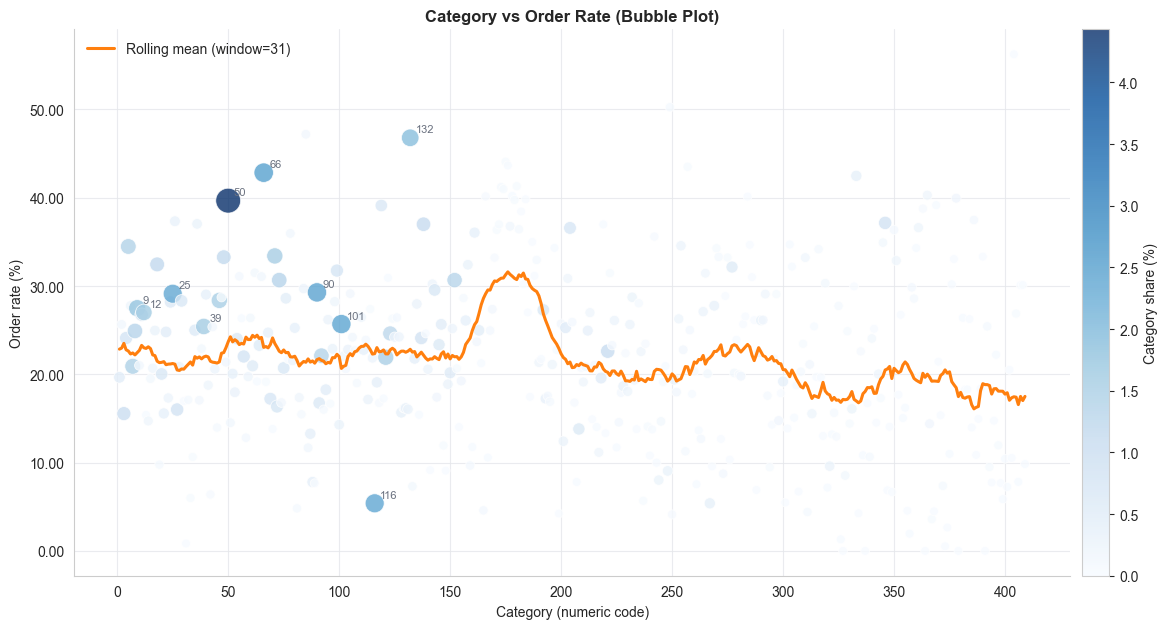

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

ATTR = "category"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

print(
    "items.csv category distribution:",
    items_df[ATTR].value_counts(dropna=False).sort_index().to_dict()
    if ATTR in items_df.columns
    else f"{ATTR} column not found",
)

if ATTR in src_df.columns:
    work_df = src_df.loc[:, [ATTR, "order"]].copy()
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge category: pid column is missing in train data.")
    if ATTR not in items_df.columns:
        raise ValueError("Cannot merge category: attribute not found in items data.")
    work_df = src_df.merge(items_df[["pid", ATTR]], on="pid", how="left", validate="m:1")
    work_df = work_df.loc[:, [ATTR, "order"]].copy()

work_df["order"] = pd.to_numeric(work_df["order"], errors="coerce")
work_df[ATTR] = pd.to_numeric(work_df[ATTR], errors="coerce")

valid_df = work_df.dropna(subset=[ATTR]).copy()
if valid_df.empty:
    raise ValueError("No numeric values available for category after conversion.")

# Category codes are discrete and high-cardinality: keep exact values and aggregate by category.
if np.allclose(valid_df[ATTR], np.floor(valid_df[ATTR])):
    valid_df["category_value"] = valid_df[ATTR].astype("int64")
else:
    valid_df["category_value"] = valid_df[ATTR]

valid_df = valid_df.sort_values("category_value")

dist_tbl = (
    valid_df["category_value"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("category")
    .reset_index(name="count")
)
dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

order_rate_tbl = (
    valid_df.groupby("category_value", as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
    .sort_values("category_value")
    .rename(columns={"category_value": "category"})
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

dist_print = dist_tbl.copy()
dist_print["count"] = dist_print["count"].map(lambda x: f"{int(x):,}")
dist_print["share_pct"] = dist_print["share_pct"].map(lambda x: f"{x:.2f}%")

order_print = order_rate_tbl[["category", "total_events", "orders", "order_rate_pct"]].copy()
order_print["total_events"] = order_print["total_events"].map(lambda x: f"{int(x):,}")
order_print["orders"] = order_print["orders"].map(lambda x: f"{int(x):,}")
order_print["order_rate_pct"] = order_print["order_rate_pct"].map(lambda x: f"{x:.2f}%")

print("=== category Distribution ===")
print(dist_print.to_string(index=False))
print("\n=== category Order Rate ===")
print(order_print.to_string(index=False))
print(f"\nRows excluded due to non-numeric category: {len(work_df) - len(valid_df):,}")

processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "category_distribution.csv"
order_rate_out = processed_dir / "category_order_rate.csv"
fig_out = figures_dir / "category_best_fit_plot.png"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)

plot_df = (
    order_rate_tbl.merge(dist_tbl[["category", "count", "share_pct"]], on="category", how="left")
    .sort_values("category")
    .reset_index(drop=True)
)


def scale_sizes(values, min_size=40, max_size=320):
    vals = pd.to_numeric(values, errors="coerce").fillna(0).to_numpy(dtype=float)
    vmin = float(vals.min())
    vmax = float(vals.max())
    if np.isclose(vmin, vmax):
        return np.full(vals.shape, (min_size + max_size) / 2.0)
    return np.interp(vals, [vmin, vmax], [min_size, max_size])


bubble_sizes = scale_sizes(plot_df["total_events"])

fig, ax = plt.subplots(figsize=(12.8, 6.4))

scatter = ax.scatter(
    plot_df["category"],
    plot_df["order_rate_pct"],
    s=bubble_sizes,
    c=plot_df["share_pct"],
    cmap="Blues",
    alpha=0.80,
    edgecolors="white",
    linewidths=0.6,
)

# Smooth trend to reveal global pattern across many category levels.
if len(plot_df) >= 5:
    window = min(31, max(5, len(plot_df) // 10))
    if window % 2 == 0:
        window += 1
    if window > len(plot_df):
        window = len(plot_df) if len(plot_df) % 2 == 1 else len(plot_df) - 1
    if window >= 3:
        trend = plot_df["order_rate_pct"].rolling(window=window, center=True, min_periods=max(2, window // 3)).mean()
        ax.plot(
            plot_df["category"],
            trend,
            color=viz["highlight"],
            linewidth=2.2,
            label=f"Rolling mean (window={window})",
        )

# Label the highest-volume categories for readability.
for row in plot_df.nlargest(min(10, len(plot_df)), "count").itertuples(index=False):
    category_val = float(row.category)
    if category_val.is_integer():
        label = str(int(category_val))
    else:
        label = f"{category_val:.2f}"
    ax.annotate(
        label,
        (row.category, row.order_rate_pct),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        color=viz["neutral"],
    )

ax.set_title("Category vs Order Rate (Bubble Plot)")
ax.set_xlabel("Category (numeric code)")
ax.set_ylabel("Order rate (%)")
ax.grid(axis="both", alpha=0.8, color=viz["grid"])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if ax.get_legend_handles_labels()[0]:
    ax.legend(loc="best")

cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
cbar.set_label("Category share (%)")

fig.tight_layout()
fig.savefig(fig_out, dpi=300, bbox_inches="tight")
print(f"\nSaved figure to: {fig_out.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")

plt.show()
plt.close(fig)

***group***

=== Group Output Check ===
Data type: str
Group nature: categorical
How many unique groups in train.csv? 533
Unique values count (including missing label): 533
Unique values preview: ['10II00OI', '10II10', '10II20OI', '10II21', '10II22OS', '10II30OI', '10II30OK', '10II31', '10II40OI', '10II50KO'] ...
Missing values: 0 (0.00%)
Which groups are not present in train.csv? 0
Top 25 groups cover: 45.93% of events
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/group_distribution_pareto_top25.png
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/group_order_rate_ci_min_events.png


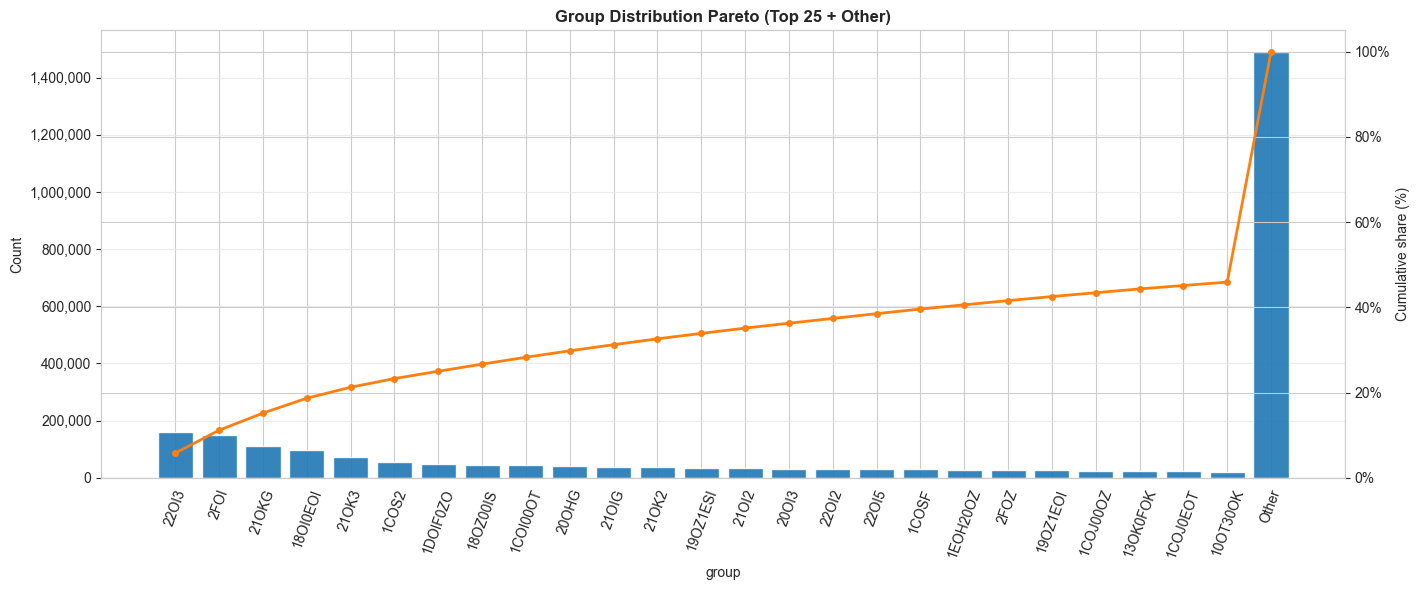

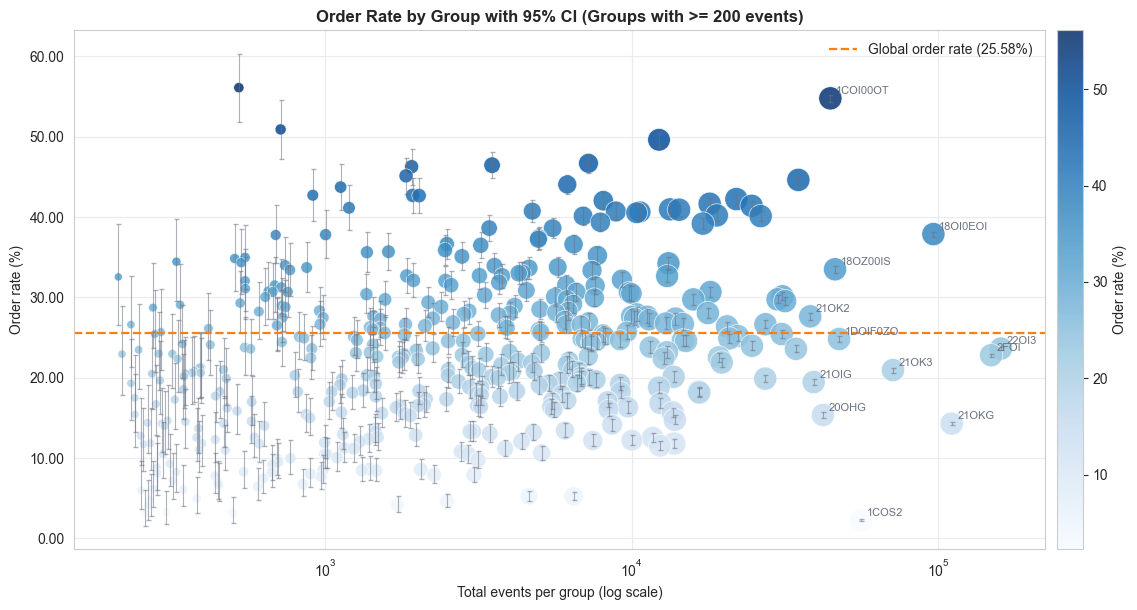


Saved tables:
/Users/annageiser/Documents/GitHub/analytics-project/data/processed/group_frequency.csv
/Users/annageiser/Documents/GitHub/analytics-project/data/processed/group_order_rate.csv
/Users/annageiser/Documents/GitHub/analytics-project/data/processed/group_order_rate_ci.csv
/Users/annageiser/Documents/GitHub/analytics-project/data/processed/group_order_rate_ci_filtered_min_events.csv


In [70]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Analysis for product attribute: group
# Primary plots only:
# - Pareto distribution plot (top groups + cumulative share)
# - Volume-aware order-rate plot with 95% CI

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

# Build source dataframe
if "train_item_set" in globals():
    group_df = train_item_set.copy()
else:
    if "train_raw_df" not in globals() or "items_raw_df" not in globals():
        raise ValueError("Need train_item_set or both train_raw_df and items_raw_df.")
    group_df = train_raw_df.merge(items_raw_df[["pid", "group"]], on="pid", how="left", validate="m:1")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

required_cols = {"group", "order", "price"}
missing_cols = required_cols - set(group_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns for group analysis: {sorted(missing_cols)}")
if "group" not in items_df.columns:
    raise ValueError("Column group is missing in items data.")

# Short output checks
group_dtype = group_df["group"].dtype
non_null_group = group_df["group"].dropna()
is_numeric_group = bool(pd.to_numeric(non_null_group, errors="coerce").notna().all()) if len(non_null_group) > 0 else False
group_nature = "numerical" if is_numeric_group else "categorical"

missing_group_count = int(group_df["group"].isna().sum())
missing_group_pct = (missing_group_count / len(group_df) * 100) if len(group_df) else 0.0

train_unique_groups = sorted(group_df["group"].dropna().astype("string").unique().tolist())
all_item_groups = set(items_df["group"].dropna().astype("string").unique().tolist())
train_unique_groups_set = set(train_unique_groups)
groups_not_in_train = sorted(all_item_groups - train_unique_groups_set)

unique_values = sorted(group_df["group"].astype("string").fillna("missing").unique().tolist())
preview_n = 10
preview_suffix = " ..." if len(unique_values) > preview_n else ""

print("=== Group Output Check ===")
print(f"Data type: {group_dtype}")
print(f"Group nature: {group_nature}")
print(f"How many unique groups in train.csv? {len(train_unique_groups):,}")
print(f"Unique values count (including missing label): {len(unique_values):,}")
print(f"Unique values preview: {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values: {missing_group_count:,} ({missing_group_pct:.2f}%)")
print(f"Which groups are not present in train.csv? {len(groups_not_in_train):,}")
if groups_not_in_train:
    sample_n = min(10, len(groups_not_in_train))
    print(f"Groups not present in train.csv (preview): {groups_not_in_train[:sample_n]}")

work = group_df.loc[:, ["group", "order", "price"]].copy()
work["group"] = work["group"].astype("string").fillna("missing")
work["order"] = pd.to_numeric(work["order"], errors="coerce")
work["price"] = pd.to_numeric(work["price"], errors="coerce")

# Core tables
freq_tbl = (
    work["group"]
    .value_counts(dropna=False)
    .rename_axis("group")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
freq_tbl["share_pct"] = (freq_tbl["count"] / freq_tbl["count"].sum() * 100).round(2)

order_rate_tbl = (
    work.groupby("group", as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
    .sort_values("total_events", ascending=False)
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

# Wilson 95% confidence interval for binomial order rates
z = 1.96
n = order_rate_tbl["total_events"].astype(float)
p = order_rate_tbl["order_rate"].astype(float)
denom = 1 + (z**2 / n)
center = (p + (z**2 / (2 * n))) / denom
margin = (z * np.sqrt((p * (1 - p) + (z**2 / (4 * n))) / n)) / denom
order_rate_tbl["order_rate_ci_low"] = np.clip(center - margin, 0, 1)
order_rate_tbl["order_rate_ci_high"] = np.clip(center + margin, 0, 1)
order_rate_tbl["order_rate_ci_low_pct"] = order_rate_tbl["order_rate_ci_low"] * 100
order_rate_tbl["order_rate_ci_high_pct"] = order_rate_tbl["order_rate_ci_high"] * 100

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

freq_out = processed_dir / "group_frequency.csv"
rate_out = processed_dir / "group_order_rate.csv"
rate_ci_out = processed_dir / "group_order_rate_ci.csv"
freq_tbl.to_csv(freq_out, index=False)
order_rate_tbl.to_csv(rate_out, index=False)
order_rate_tbl.to_csv(rate_ci_out, index=False)

# 1) Pareto distribution plot (Top N + Other + cumulative share)
top_n_pareto = 25
pareto_base = freq_tbl.copy()
other_count = int(pareto_base.iloc[top_n_pareto:]["count"].sum())
pareto_plot = pareto_base.head(top_n_pareto).copy()
if other_count > 0:
    pareto_plot = pd.concat(
        [
            pareto_plot,
            pd.DataFrame(
                {
                    "group": ["Other"],
                    "count": [other_count],
                    "share_pct": [round(other_count / pareto_base["count"].sum() * 100, 2)],
                }
            ),
        ],
        ignore_index=True,
    )
pareto_plot["cum_share_pct"] = pareto_plot["count"].cumsum() / pareto_base["count"].sum() * 100

fig1_width = min(20, max(14, len(pareto_plot) * 0.55))
fig1, ax1 = plt.subplots(figsize=(fig1_width, 6.0))
ax1.bar(
    pareto_plot["group"],
    pareto_plot["count"],
    color=viz["primary"],
    alpha=0.9,
)
ax1.set_title(f"Group Distribution Pareto (Top {top_n_pareto} + Other)")
ax1.set_xlabel("group")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=70)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax1.grid(axis="y", color=viz["grid"], alpha=0.8)

ax1b = ax1.twinx()
ax1b.plot(
    pareto_plot["group"],
    pareto_plot["cum_share_pct"],
    color=viz["highlight"],
    marker="o",
    linewidth=2.0,
    markersize=4,
)
ax1b.set_ylabel("Cumulative share (%)")
ax1b.set_ylim(0, 105)
ax1b.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))

top_share = float(pareto_base.head(top_n_pareto)["count"].sum() / pareto_base["count"].sum() * 100)
print(f"Top {top_n_pareto} groups cover: {top_share:.2f}% of events")

fig1.tight_layout()
fig1_path = figures_dir / "group_distribution_pareto_top25.png"
fig1.savefig(fig1_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig1_path.resolve()}")

# 2) Volume-aware order-rate plot with 95% CI
min_events_for_rate = 200
rate_ci_plot = order_rate_tbl[order_rate_tbl["total_events"] >= min_events_for_rate].copy()
if rate_ci_plot.empty:
    raise ValueError(f"No groups meet min_events_for_rate={min_events_for_rate} for CI order-rate plot.")

rate_ci_plot = rate_ci_plot.sort_values("order_rate_pct", ascending=False)
ci_low = rate_ci_plot["order_rate_pct"] - rate_ci_plot["order_rate_ci_low_pct"]
ci_high = rate_ci_plot["order_rate_ci_high_pct"] - rate_ci_plot["order_rate_pct"]

global_order_rate_pct = float(work["order"].mean() * 100)

fig2, ax2 = plt.subplots(figsize=(12.5, 6.2))
ax2.errorbar(
    rate_ci_plot["total_events"],
    rate_ci_plot["order_rate_pct"],
    yerr=[ci_low, ci_high],
    fmt="none",
    ecolor=viz["neutral"],
    elinewidth=0.8,
    alpha=0.55,
    capsize=1.8,
)
scatter = ax2.scatter(
    rate_ci_plot["total_events"],
    rate_ci_plot["order_rate_pct"],
    s=np.clip(np.sqrt(rate_ci_plot["total_events"]) * 2.4, 30, 280),
    c=rate_ci_plot["order_rate_pct"],
    cmap="Blues",
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
)
ax2.axhline(global_order_rate_pct, color=viz["highlight"], linestyle="--", linewidth=1.6, label=f"Global order rate ({global_order_rate_pct:.2f}%)")
ax2.set_xscale("log")
ax2.set_title(f"Order Rate by Group with 95% CI (Groups with >= {min_events_for_rate} events)")
ax2.set_xlabel("Total events per group (log scale)")
ax2.set_ylabel("Order rate (%)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax2.grid(axis="both", color=viz["grid"], alpha=0.8)
ax2.legend(loc="best")

for row in rate_ci_plot.nlargest(min(12, len(rate_ci_plot)), "total_events").itertuples(index=False):
    ax2.annotate(
        row.group,
        (row.total_events, row.order_rate_pct),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=8,
        color=viz["neutral"],
    )

cbar = fig2.colorbar(scatter, ax=ax2, pad=0.01)
cbar.set_label("Order rate (%)")

rate_ci_filtered_out = processed_dir / "group_order_rate_ci_filtered_min_events.csv"
rate_ci_plot.to_csv(rate_ci_filtered_out, index=False)

fig2.tight_layout()
fig2_path = figures_dir / "group_order_rate_ci_min_events.png"
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig2_path.resolve()}")

plt.show()
plt.close(fig1)
plt.close(fig2)

print("\nSaved tables:")
print(freq_out.resolve())
print(rate_out.resolve())
print(rate_ci_out.resolve())
print(rate_ci_filtered_out.resolve())

***pharmForm***

=== pharmForm Output Check ===
Data type: str
Attribute nature: categorical
Unique values count in items.csv (non-missing): 278
Unique values count in items.csv (including missing label): 279
Unique values count in merged event dataset: 279
Unique values preview (merged): ['AEO', 'AMP', 'APA', 'ASN', 'ATR', 'AUB', 'AUC', 'AUG', 'AUS', 'Aeo', 'Amp', 'Atr'] ...
Missing values count in items.csv: 2,327
Missing values count in train.csv (after merge by pid): 194,124
Missing values in merged event dataset: 194,124 (7.04%)
pharmForm values in items.csv not represented in merged dataset: 0
Outliers (rare levels): 190 (68.35% of non-missing levels)
Outlier preview: ['OHT', 'ZCR', 'DIL', 'SPL', 'VER', 'TON', 'VSU', 'Kap', 'SPF', 'FLA']
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/pharmform_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/pharmform_distribution.csv
Saved table to: /Users/annageiser/Do

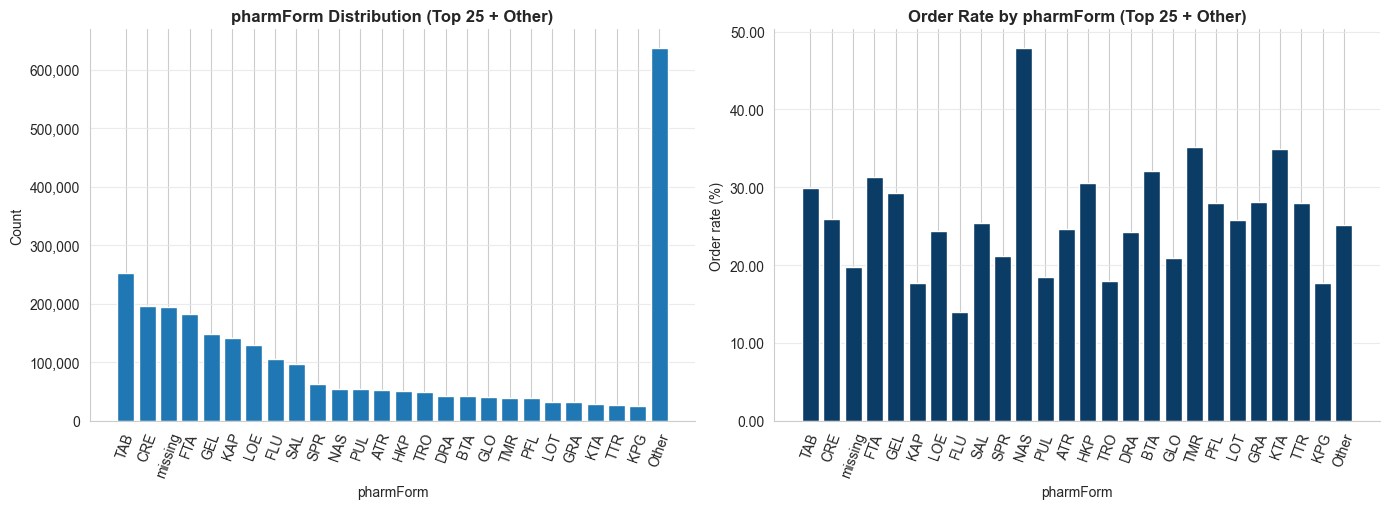

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: pharmForm
# Checks:
# - data type
# - categorical or numerical
# - unique values
# - missing values
# - outliers
# - distribution
# - order rate
# ============================================================

attr_candidates = ["pharmForm", "pharmform"]

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

# Bring pharmForm to event-level train rows if it is not already present there.
if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge pharmForm: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce")

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()
is_numeric_attr = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
attr_nature = "numerical" if is_numeric_attr else "categorical"

# Separate source-level checks requested by user
items_attr_series = items_df[attr]
items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
items_missing_count = int(items_attr_series.isna().sum())

# train.csv does not carry pharmForm natively, so missing is measured on event-level rows after merge
train_missing_count = int(attr_series.isna().sum())

item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
not_represented_values = sorted(item_values_set - merged_values_set)
not_represented_count = len(not_represented_values)

missing_count = train_missing_count
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""

# Outlier check
if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()
    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100) if len(numeric_values) else 0.0
        outlier_tbl = pd.DataFrame({
            "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
            "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
        })
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()
    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)
    rare_threshold_abs = max(10, int(len(work) * 0.001))
    rare_levels = level_counts[level_counts <= rare_threshold_abs]
    outlier_count = int(len(rare_levels))
    outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
    outlier_tbl = (
        rare_levels.rename_axis(attr)
        .reset_index(name="count")
        .assign(outlier_rule=f"rare_level_count_le_{rare_threshold_abs}")
    )
    outlier_preview = rare_levels.head(10).index.tolist()

# Distribution table
dist_tbl = (
    display_attr.value_counts(dropna=False)
    .rename_axis(attr)
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

# Order-rate table
order_rate_tbl = (
    pd.DataFrame({attr: display_attr, "order": work["order"]})
    .groupby(attr, as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
)
order_rate_tbl["order_rate"] = order_rate_tbl["orders"] / order_rate_tbl["total_events"]
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
order_rate_tbl = order_rate_tbl.sort_values("total_events", ascending=False)

# Console checks
print("=== pharmForm Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in items.csv: {items_missing_count:,}")
print(f"Missing values count in train.csv (after merge by pid): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
print(f"pharmForm values in items.csv not represented in merged dataset: {not_represented_count:,}")
if not_represented_values:
    sample_n = min(12, len(not_represented_values))
    print(f"Not represented values preview: {not_represented_values[:sample_n]}")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
else:
    print(f"Outliers (rare levels): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "pharmform_distribution.csv"
order_rate_out = processed_dir / "pharmform_order_rate.csv"
outlier_out = processed_dir / "pharmform_outlier_report.csv"
not_represented_out = processed_dir / "pharmform_not_represented_in_merged.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
pd.DataFrame({attr: not_represented_values}).to_csv(not_represented_out, index=False)

# Plot distribution and order rate with readable top-N strategy
top_n = 25

dist_plot = dist_tbl.head(top_n).copy()
if len(dist_tbl) > top_n:
    other_count = int(dist_tbl.iloc[top_n:]["count"].sum())
    dist_plot = pd.concat(
        [
            dist_plot,
            pd.DataFrame({attr: ["Other"], "count": [other_count], "share_pct": [round(other_count / dist_tbl["count"].sum() * 100, 2)]}),
        ],
        ignore_index=True,
    )

selected_levels = dist_plot[attr].astype("string").tolist()
if "Other" in selected_levels:
    selected_levels_no_other = [x for x in selected_levels if x != "Other"]
    order_subset = order_rate_tbl[order_rate_tbl[attr].astype("string").isin(selected_levels_no_other)].copy()
    if len(order_rate_tbl) > len(order_subset):
        other_total_events = int(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "total_events"].sum())
        other_orders = float(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "orders"].sum())
        other_rate = (other_orders / other_total_events) if other_total_events > 0 else np.nan
        order_subset = pd.concat(
            [
                order_subset,
                pd.DataFrame(
                    {
                        attr: ["Other"],
                        "total_events": [other_total_events],
                        "orders": [other_orders],
                        "order_rate": [other_rate],
                        "order_rate_pct": [round(other_rate * 100, 2) if pd.notna(other_rate) else np.nan],
                    }
                ),
            ],
            ignore_index=True,
        )
    order_plot = order_subset.set_index(attr).reindex(selected_levels).reset_index()
else:
    order_plot = order_rate_tbl.head(top_n).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].bar(dist_plot[attr].astype(str), dist_plot["count"], color=viz["primary"])
axes[0].set_title(f"pharmForm Distribution")
axes[0].set_xlabel("pharmForm")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].tick_params(axis="x", rotation=70)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(order_plot[attr].astype(str), order_plot["order_rate_pct"], color=viz["primary_dark"])
axes[1].set_title(f"Order Rate by pharmForm")
axes[1].set_xlabel("pharmForm")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2f}"))
axes[1].tick_params(axis="x", rotation=70)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "pharmform_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig)

***manufacturer***

=== manufacturer Output Check ===
Data type: int64
Attribute nature: categorical
Unique values count in items.csv (non-missing): 1,067
Unique values count in items.csv (including missing label): 1,067
Unique values count in merged event dataset: 1,065
Unique values preview (merged): ['1', '10', '100', '1000', '1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008'] ...
Missing values count in items.csv: 0
Missing values count in train.csv (after merge by pid): 0
Missing values in merged event dataset: 0 (0.00%)
manufacturer values in items.csv not represented in merged dataset: 2
Not represented values preview: ['332', '576']
Outliers (rare levels): 894 (83.94% of non-missing levels)
Outlier preview: ['238', '735', '322', '378', '185', '14', '520', '532', '609', '256']
Levels retained for CI rate chart (min events 500): 373
Top 25 manufacturers cover: 47.34% of events (tail: 52.66%).
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/manufacturer_distr

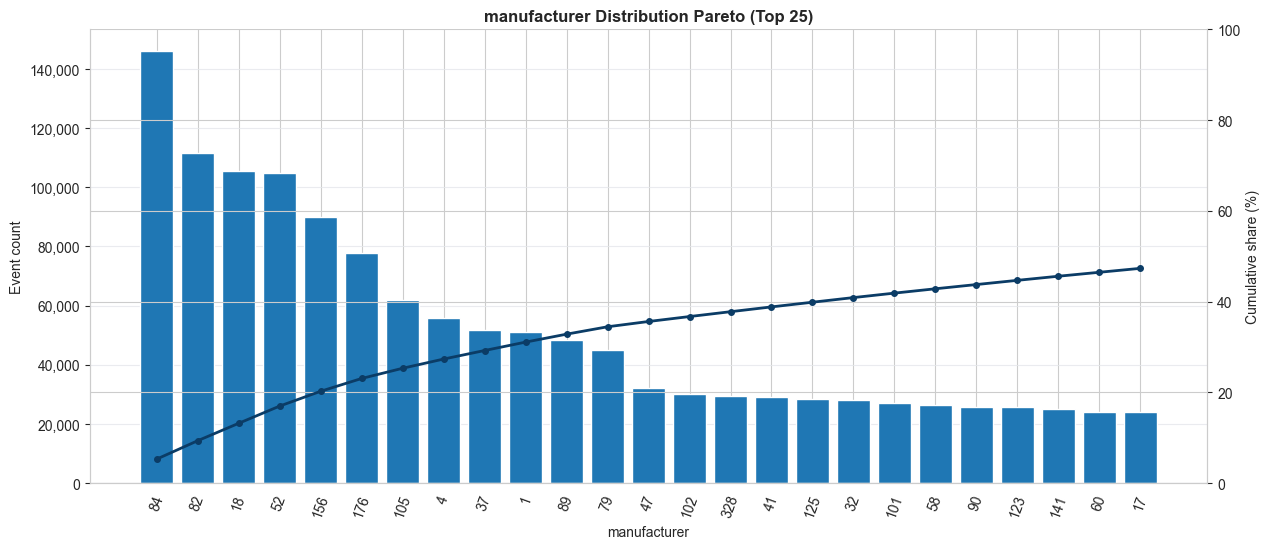

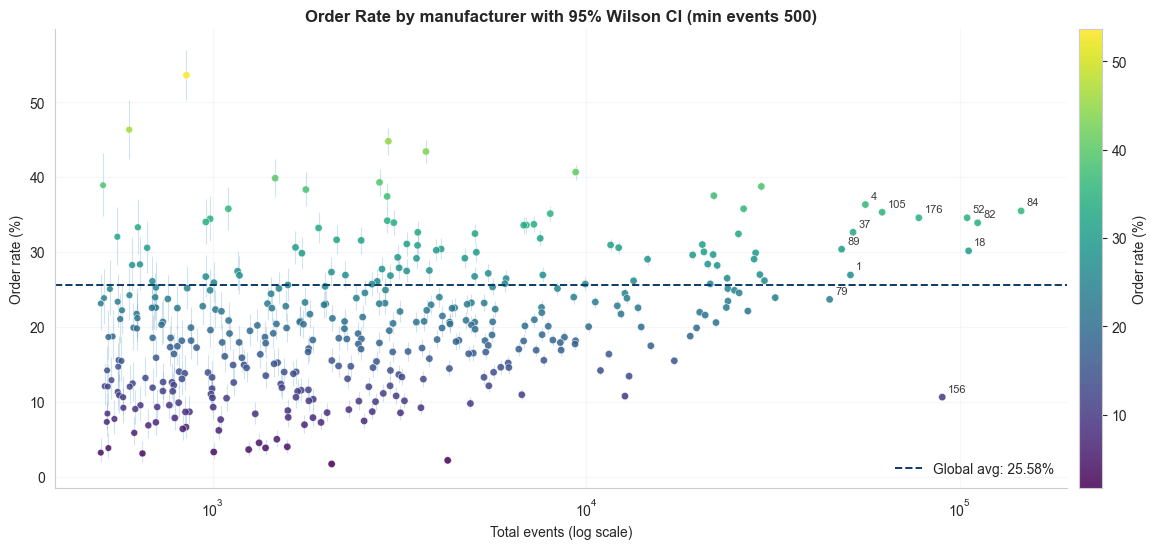

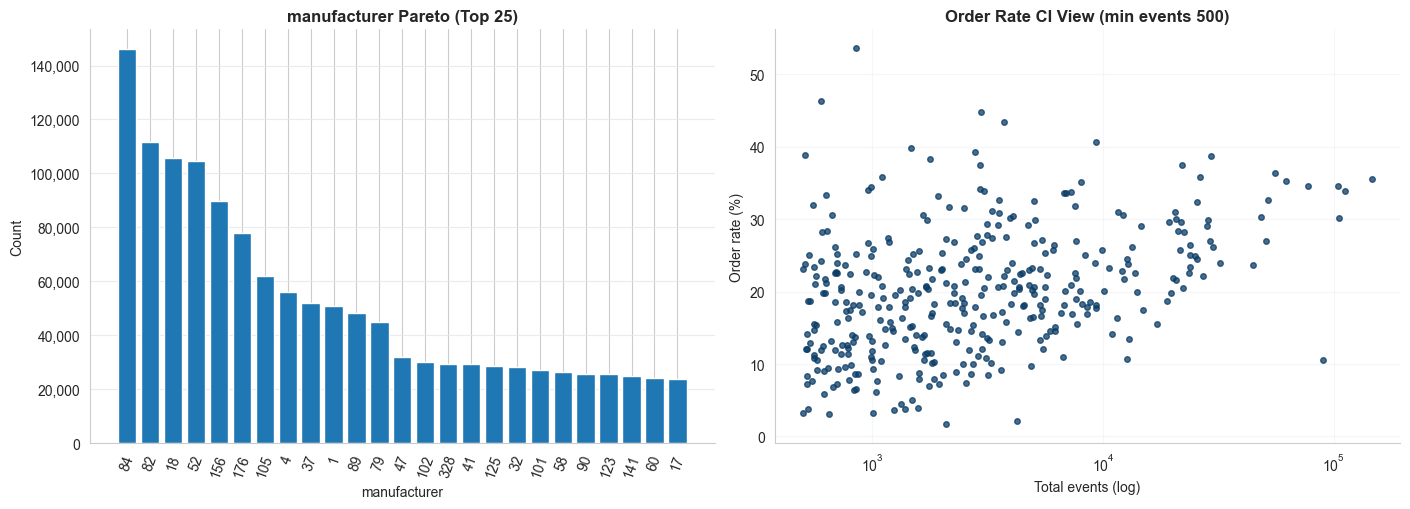

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: manufacturer
# Checks:
# - data type
# - categorical or numerical
# - unique values count from items.csv
# - missing values count from items.csv and train.csv separately
# - outliers
# - distribution
# - order rate
# - how many values from items.csv are not represented in merged dataset
# ============================================================

attr_candidates = ["manufacturer", "Manufacturer"]

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS
accent_color = viz.get("accent", viz.get("primary_dark", "#1f77b4"))

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

# Bring manufacturer to event-level train rows if not already present there.
if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
    train_missing_count = int(src_df[attr].isna().sum())
    train_missing_context = "directly in train.csv"
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge manufacturer: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr
    train_missing_count = int(work_df[attr].isna().sum())
    train_missing_context = "after merge by pid"

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce").fillna(0)

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()

detected_numeric = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
identifier_like_fields = {"manufacturer", "Manufacturer"}
is_numeric_attr = detected_numeric and (attr not in identifier_like_fields)
attr_nature = "numerical" if is_numeric_attr else "categorical"

# Source-level checks requested by user
items_attr_series = items_df[attr]
items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
items_missing_count = int(items_attr_series.isna().sum())

item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
not_represented_values = sorted(item_values_set - merged_values_set)
not_represented_count = len(not_represented_values)

missing_count = int(attr_series.isna().sum())
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""

# Outlier check
if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()
    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100) if len(numeric_values) else 0.0
        outlier_tbl = pd.DataFrame(
            {
                "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
                "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
            }
        )
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()
    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)
    rare_threshold_abs = max(10, int(len(work) * 0.001))
    rare_levels = level_counts[level_counts <= rare_threshold_abs]
    outlier_count = int(len(rare_levels))
    outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
    outlier_tbl = (
        rare_levels.rename_axis(attr)
        .reset_index(name="count")
        .assign(outlier_rule=f"rare_level_count_le_{rare_threshold_abs}")
    )
    outlier_preview = rare_levels.head(10).index.tolist()

# Distribution table
dist_tbl = (
    display_attr.value_counts(dropna=False)
    .rename_axis(attr)
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

# Order-rate table
order_rate_tbl = (
    pd.DataFrame({attr: display_attr, "order": work["order"]})
    .groupby(attr, as_index=False)
    .agg(total_events=("order", "size"), orders=("order", "sum"))
)
order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
order_rate_tbl = order_rate_tbl.sort_values("total_events", ascending=False)

# Wilson 95% confidence interval for order rate
z = 1.96
n = order_rate_tbl["total_events"].astype(float)
p = order_rate_tbl["order_rate"].astype(float)
denom = 1 + (z ** 2) / n
center = (p + (z ** 2) / (2 * n)) / denom
margin = (z * np.sqrt((p * (1 - p) / n) + ((z ** 2) / (4 * n ** 2)))) / denom
order_rate_tbl["order_rate_ci_low"] = (center - margin).clip(lower=0)
order_rate_tbl["order_rate_ci_high"] = (center + margin).clip(upper=1)

# Keep only sufficiently supported manufacturers for CI ranking view
min_events_for_rate = 500
rate_ci_plot = (
    order_rate_tbl[order_rate_tbl["total_events"] >= min_events_for_rate]
    .sort_values("order_rate", ascending=False)
    .copy()
)

# Console checks
print("=== manufacturer Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in items.csv: {items_missing_count:,}")
print(f"Missing values count in train.csv ({train_missing_context}): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
print(f"manufacturer values in items.csv not represented in merged dataset: {not_represented_count:,}")
if not_represented_values:
    sample_n = min(12, len(not_represented_values))
    print(f"Not represented values preview: {not_represented_values[:sample_n]}")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
else:
    print(f"Outliers (rare levels): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")
print(f"Levels retained for CI rate chart (min events {min_events_for_rate:,}): {len(rate_ci_plot):,}")

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "manufacturer_distribution.csv"
order_rate_out = processed_dir / "manufacturer_order_rate.csv"
outlier_out = processed_dir / "manufacturer_outlier_report.csv"
not_represented_out = processed_dir / "manufacturer_not_represented_in_merged.csv"
rate_ci_out = processed_dir / "manufacturer_order_rate_ci.csv"
rate_ci_filtered_out = processed_dir / f"manufacturer_order_rate_ci_filtered_min_events_{min_events_for_rate}.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
pd.DataFrame({attr: not_represented_values}).to_csv(not_represented_out, index=False)
order_rate_tbl.to_csv(rate_ci_out, index=False)
rate_ci_plot.to_csv(rate_ci_filtered_out, index=False)

# Plot 1: Pareto chart for concentration (Top N + cumulative share)
top_n_pareto = 25
pareto_plot = dist_tbl.head(top_n_pareto).copy()
pareto_plot["cum_share_pct"] = pareto_plot["count"].cumsum() / dist_tbl["count"].sum() * 100

top_share = float(pareto_plot["cum_share_pct"].iloc[-1]) if len(pareto_plot) else 0.0
tail_share = 100 - top_share
print(f"Top {top_n_pareto} manufacturers cover: {top_share:.2f}% of events (tail: {tail_share:.2f}%).")

fig1, ax1 = plt.subplots(figsize=(12.8, 5.6))
ax1.bar(pareto_plot[attr].astype(str), pareto_plot["count"], color=viz["primary"])
ax1.set_title(f"manufacturer Distribution Pareto (Top {top_n_pareto})")
ax1.set_xlabel("manufacturer")
ax1.set_ylabel("Event count")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
ax1.grid(axis="y", alpha=0.8, color=viz["grid"])
ax1.tick_params(axis="x", rotation=70)
ax1.spines["top"].set_visible(False)

ax1b = ax1.twinx()
ax1b.plot(
    pareto_plot[attr].astype(str),
    pareto_plot["cum_share_pct"],
    color=accent_color,
    marker="o",
    linewidth=2,
    markersize=4,
)
ax1b.set_ylabel("Cumulative share (%)")
ax1b.set_ylim(0, 100)
ax1b.spines["top"].set_visible(False)

fig1.tight_layout()
fig1_path = figures_dir / f"manufacturer_distribution_pareto_top{top_n_pareto}.png"
fig1.savefig(fig1_path, dpi=300, bbox_inches="tight")

# Plot 2: Order-rate with Wilson CI and log-scaled exposure axis
fig2, ax2 = plt.subplots(figsize=(12.8, 5.6))
if len(rate_ci_plot) > 0:
    x = rate_ci_plot["total_events"].to_numpy(dtype=float)
    y = rate_ci_plot["order_rate"].to_numpy(dtype=float) * 100
    ci_low = rate_ci_plot["order_rate_ci_low"].to_numpy(dtype=float) * 100
    ci_high = rate_ci_plot["order_rate_ci_high"].to_numpy(dtype=float) * 100

    yerr = np.vstack([y - ci_low, ci_high - y])
    ax2.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="none",
        ecolor=viz["primary"],
        alpha=0.20,
        elinewidth=0.8,
        capsize=0,
        zorder=1,
    )

    size_scale = np.clip(np.sqrt(x), 8, 28)
    scatter = ax2.scatter(
        x,
        y,
        s=size_scale,
        c=y,
        cmap="viridis",
        alpha=0.85,
        edgecolors="white",
        linewidths=0.4,
        zorder=2,
    )
    cbar = plt.colorbar(scatter, ax=ax2, pad=0.01)
    cbar.set_label("Order rate (%)")

    global_order_rate_pct = float(work["order"].mean() * 100)
    ax2.axhline(global_order_rate_pct, color=accent_color, linestyle="--", linewidth=1.4, label=f"Global avg: {global_order_rate_pct:.2f}%")

    # Label only the largest supported manufacturers for readability.
    for _, row in rate_ci_plot.sort_values("total_events", ascending=False).head(12).iterrows():
        ax2.annotate(
            str(row[attr]),
            (row["total_events"], row["order_rate"] * 100),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
            alpha=0.9,
        )

    ax2.set_xscale("log")
    ax2.legend(frameon=False, loc="lower right")

ax2.set_title(f"Order Rate by manufacturer with 95% Wilson CI (min events {min_events_for_rate})")
ax2.set_xlabel("Total events (log scale)")
ax2.set_ylabel("Order rate (%)")
ax2.grid(axis="both", alpha=0.35, color=viz["grid"])
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig2.tight_layout()
fig2_path = figures_dir / f"manufacturer_order_rate_ci_min_events_{min_events_for_rate}.png"
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")

# Optional combined figure to keep previous output path stable
fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.2))

axes[0].bar(pareto_plot[attr].astype(str), pareto_plot["count"], color=viz["primary"])
axes[0].set_title(f"manufacturer Pareto (Top {top_n_pareto})")
axes[0].set_xlabel("manufacturer")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.8, color=viz["grid"])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].tick_params(axis="x", rotation=70)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].scatter(rate_ci_plot["total_events"], rate_ci_plot["order_rate"] * 100, s=16, alpha=0.75, color=viz["primary_dark"])
axes[1].set_xscale("log")
axes[1].set_title(f"Order Rate CI View (min events {min_events_for_rate})")
axes[1].set_xlabel("Total events (log)")
axes[1].set_ylabel("Order rate (%)")
axes[1].grid(axis="both", alpha=0.35, color=viz["grid"])
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "manufacturer_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig1_path.resolve()}")
print(f"Saved figure to: {fig2_path.resolve()}")
print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {rate_ci_out.resolve()}")
print(f"Saved table to: {rate_ci_filtered_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig1)
plt.close(fig2)
plt.close(fig)

***salesIndex***

=== salesIndex Output Check ===
Data type: int64
Attribute nature: numerical
Unique values count in items.csv (non-missing): 4
Unique values count in items.csv (including missing label): 4
Unique values count in merged event dataset: 4
Unique values preview (merged): ['40', '44', '52', '53']
Missing values count in items.csv: 0
Missing values count in train.csv (after merge by pid): 0
Missing values in merged event dataset: 0 (0.00%)
salesIndex values in items.csv not represented in merged dataset: 0
Outliers (IQR 1.5 rule): 0 (0.00% of non-missing)
Plot mode: exact Sales Index value bars for distribution and order rate.
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/salesindex_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/salesindex_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/salesindex_order_rate.csv
Saved table to: /Users/annageise

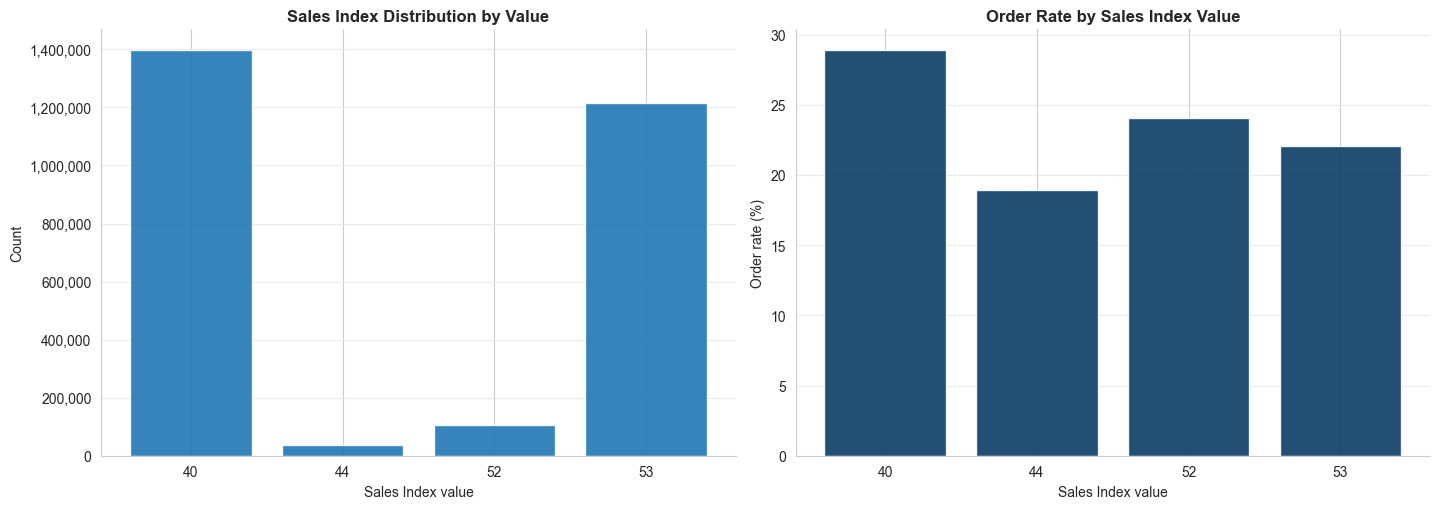

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: salesIndex
# Checks:
# - data type
# - categorical or numerical
# - unique values count from items.csv
# - missing values count from items.csv and train.csv separately
# - outliers
# - distribution
# - order rate
# - how many values from items.csv are not represented in merged dataset
# ============================================================

attr_candidates = ["salesIndex", "salesindex", "SalesIndex"]
display_name = "Sales Index"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS
primary_color = viz.get("primary", "#4c78a8")
primary_dark_color = viz.get("primary_dark", "#2f5597")
grid_color = viz.get("grid", "#d0d0d0")

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
    train_missing_count = int(src_df[attr].isna().sum())
    train_missing_context = "directly in train.csv"
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge salesIndex: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr
    train_missing_count = int(work_df[attr].isna().sum())
    train_missing_context = "after merge by pid"

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce").fillna(0)

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()

is_numeric_attr = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
attr_nature = "numerical" if is_numeric_attr else "categorical"

# Source-level checks requested by user
items_attr_series = items_df[attr]
items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
items_missing_count = int(items_attr_series.isna().sum())

item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
not_represented_values = sorted(item_values_set - merged_values_set)
not_represented_count = len(not_represented_values)

missing_count = int(attr_series.isna().sum())
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""
numeric_order_mode = ""

# Outlier check + branch-specific distribution/order-rate preparation
if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()

    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100) if len(numeric_values) else 0.0
        outlier_tbl = pd.DataFrame(
            {
                "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
                "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
            }
        )
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()

        numeric_work = pd.DataFrame(
            {
                "value": pd.to_numeric(work[attr], errors="coerce"),
                "order": work["order"],
            }
        ).dropna(subset=["value"])

        n_unique_numeric = int(numeric_work["value"].nunique())

        # For low-cardinality numeric values, treat as discrete values instead of histogram bins.
        if n_unique_numeric <= 20:
            numeric_order_mode = "value"

            dist_tbl = (
                numeric_work.groupby("value", as_index=False)
                .agg(count=("order", "size"))
                .sort_values("value")
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)
            dist_tbl["value_label"] = dist_tbl["value"].map(lambda v: f"{v:g}")

            order_rate_tbl = (
                numeric_work.groupby("value", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"))
                .sort_values("value")
            )
            order_rate_tbl["avg_salesIndex"] = order_rate_tbl["value"]
            order_rate_tbl["bin"] = order_rate_tbl["value"].map(lambda v: f"{v:g}")
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

        else:
            numeric_order_mode = "quantile_bin"

            # Distribution: histogram bins
            x_min = float(numeric_values.min())
            x_max = float(numeric_values.max())
            if x_max == x_min:
                bin_edges = np.array([x_min, x_min + 1.0], dtype=float)
            else:
                iqr_spread = float(numeric_values.quantile(0.75) - numeric_values.quantile(0.25))
                n = len(numeric_values)
                if iqr_spread > 0 and n > 1:
                    bw = 2 * iqr_spread / (n ** (1 / 3))
                    bin_count = int(np.ceil((x_max - x_min) / bw)) if bw > 0 else 30
                else:
                    bin_count = min(30, max(10, int(np.sqrt(n))))
                bin_count = max(10, min(60, bin_count))
                bin_edges = np.linspace(x_min, x_max, bin_count + 1)

            counts, edges = np.histogram(numeric_values, bins=bin_edges)
            dist_tbl = pd.DataFrame(
                {
                    "bin_left": edges[:-1],
                    "bin_right": edges[1:],
                    "count": counts,
                }
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

            q_bins = int(min(10, max(2, n_unique_numeric)))
            try:
                numeric_work["bin"] = pd.qcut(numeric_work["value"], q=q_bins, duplicates="drop")
            except ValueError:
                numeric_work["bin"] = pd.cut(numeric_work["value"], bins=q_bins, include_lowest=True)

            order_rate_tbl = (
                numeric_work.groupby("bin", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"), avg_salesIndex=("value", "mean"))
                .sort_values("avg_salesIndex")
            )
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
            order_rate_tbl["bin"] = order_rate_tbl["bin"].astype("string")

    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
        dist_tbl = pd.DataFrame(columns=["value", "count", "share_pct", "value_label"])
        order_rate_tbl = pd.DataFrame(columns=["value", "bin", "total_events", "orders", "avg_salesIndex", "order_rate", "order_rate_pct"])

else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)
    rare_threshold_abs = max(10, int(len(work) * 0.001))
    rare_levels = level_counts[level_counts <= rare_threshold_abs]
    outlier_count = int(len(rare_levels))
    outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
    outlier_tbl = (
        rare_levels.rename_axis(attr)
        .reset_index(name="count")
        .assign(outlier_rule=f"rare_level_count_le_{rare_threshold_abs}")
    )
    outlier_preview = rare_levels.head(10).index.tolist()

    dist_tbl = (
        display_attr.value_counts(dropna=False)
        .rename_axis(attr)
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

    order_rate_tbl = (
        pd.DataFrame({attr: display_attr, "order": work["order"]})
        .groupby(attr, as_index=False)
        .agg(total_events=("order", "size"), orders=("order", "sum"))
    )
    order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
    order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
    order_rate_tbl = order_rate_tbl.sort_values("total_events", ascending=False)

# Console checks
print("=== salesIndex Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in items.csv: {items_missing_count:,}")
print(f"Missing values count in train.csv ({train_missing_context}): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
print(f"salesIndex values in items.csv not represented in merged dataset: {not_represented_count:,}")
if not_represented_values:
    sample_n = min(12, len(not_represented_values))
    print(f"Not represented values preview: {not_represented_values[:sample_n]}")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
    if numeric_order_mode == "value":
        print("Plot mode: exact Sales Index value bars for distribution and order rate.")
    elif numeric_order_mode == "quantile_bin":
        print("Plot mode: histogram + quantile-bin order-rate curve.")
else:
    print(f"Outliers (rare levels): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "salesindex_distribution.csv"
order_rate_out = processed_dir / "salesindex_order_rate.csv"
outlier_out = processed_dir / "salesindex_outlier_report.csv"
not_represented_out = processed_dir / "salesindex_not_represented_in_merged.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
pd.DataFrame({attr: not_represented_values}).to_csv(not_represented_out, index=False)

# Plot distribution and order rate
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

if is_numeric_attr:
    if numeric_order_mode == "value":
        if len(dist_tbl) > 0:
            axes[0].bar(dist_tbl["value_label"].astype(str), dist_tbl["count"], color=primary_color, alpha=0.9)
        axes[0].set_title(f"{display_name} Distribution by Value")
        axes[0].set_xlabel(f"{display_name} value")
        axes[0].set_ylabel("Count")
        axes[0].grid(axis="y", alpha=0.8, color=grid_color)
        axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
        axes[0].spines["top"].set_visible(False)
        axes[0].spines["right"].set_visible(False)

        if len(order_rate_tbl) > 0:
            x_pos = np.arange(len(order_rate_tbl))
            y = order_rate_tbl["order_rate_pct"].to_numpy(dtype=float)
            axes[1].bar(x_pos, y, color=primary_dark_color, alpha=0.9)
            axes[1].set_xticks(x_pos)
            axes[1].set_xticklabels(order_rate_tbl["bin"].astype(str))

        axes[1].set_title(f"Order Rate by {display_name} Value")
        axes[1].set_xlabel(f"{display_name} value")
        axes[1].set_ylabel("Order rate (%)")
        axes[1].grid(axis="y", alpha=0.8, color=grid_color)
        axes[1].spines["top"].set_visible(False)
        axes[1].spines["right"].set_visible(False)

    else:
        if len(dist_tbl) > 0:
            bin_centers = (dist_tbl["bin_left"] + dist_tbl["bin_right"]) / 2
            bin_width = (dist_tbl["bin_right"] - dist_tbl["bin_left"]).median() if len(dist_tbl) > 1 else 1.0
            axes[0].bar(bin_centers, dist_tbl["count"], width=bin_width * 0.95, color=primary_color, alpha=0.9)
        axes[0].set_title(f"{display_name} Distribution (Histogram)")
        axes[0].set_xlabel(display_name)
        axes[0].set_ylabel("Count")
        axes[0].grid(axis="y", alpha=0.8, color=grid_color)
        axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
        axes[0].spines["top"].set_visible(False)
        axes[0].spines["right"].set_visible(False)

        if len(order_rate_tbl) > 0:
            axes[1].plot(order_rate_tbl["bin"].astype(str), order_rate_tbl["order_rate_pct"], marker="o", color=primary_dark_color, linewidth=1.8)
            axes[1].tick_params(axis="x", rotation=35)
        axes[1].set_title(f"Order Rate by {display_name} Quantile Bin")
        axes[1].set_xlabel(f"{display_name} group")
        axes[1].set_ylabel("Order rate (%)")
        axes[1].grid(axis="y", alpha=0.8, color=grid_color)
        axes[1].spines["top"].set_visible(False)
        axes[1].spines["right"].set_visible(False)

else:
    top_n = 25
    dist_plot = dist_tbl.head(top_n).copy()
    if len(dist_tbl) > top_n:
        other_count = int(dist_tbl.iloc[top_n:]["count"].sum())
        dist_plot = pd.concat(
            [
                dist_plot,
                pd.DataFrame({attr: ["Other"], "count": [other_count], "share_pct": [round(other_count / dist_tbl["count"].sum() * 100, 2)]}),
            ],
            ignore_index=True,
        )

    selected_levels = dist_plot[attr].astype("string").tolist()
    if "Other" in selected_levels:
        selected_levels_no_other = [x for x in selected_levels if x != "Other"]
        order_subset = order_rate_tbl[order_rate_tbl[attr].astype("string").isin(selected_levels_no_other)].copy()
        if len(order_rate_tbl) > len(order_subset):
            other_total_events = int(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "total_events"].sum())
            other_orders = float(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "orders"].sum())
            other_rate = (other_orders / other_total_events) if other_total_events > 0 else np.nan
            order_subset = pd.concat(
                [
                    order_subset,
                    pd.DataFrame(
                        {
                            attr: ["Other"],
                            "total_events": [other_total_events],
                            "orders": [other_orders],
                            "order_rate": [other_rate],
                            "order_rate_pct": [round(other_rate * 100, 2) if pd.notna(other_rate) else np.nan],
                        }
                    ),
                ],
                ignore_index=True,
            )
        order_plot = order_subset.set_index(attr).reindex(selected_levels).reset_index()
    else:
        order_plot = order_rate_tbl.head(top_n).copy()

    axes[0].bar(dist_plot[attr].astype(str), dist_plot["count"], color=primary_color)
    axes[0].set_title(f"{display_name} Distribution")
    axes[0].set_xlabel(display_name)
    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].tick_params(axis="x", rotation=70)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].bar(order_plot[attr].astype(str), order_plot["order_rate_pct"], color=primary_dark_color)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(display_name)
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=70)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "salesindex_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig)

***content***

=== content Output Check ===
Data type: str
Attribute nature: categorical
Unique values count in items.csv (non-missing): 548
Unique values count in items.csv (including missing label): 548
Unique values count in merged event dataset: 548
Unique values preview (merged): ['0.25', '0.5', '1', '1.1', '1.14', '1.19', '1.3', '1.5', '10', '100', '1000', '100X0.5'] ...
Missing values count in items.csv: 0
Missing values count in train.csv (after merge by pid): 0
Missing values in merged event dataset: 0 (0.00%)
content values in items.csv not represented in merged dataset: 0
Outliers (rare levels): 488 (89.05% of non-missing levels)
Outlier preview: ['350', '25X2', '750', '45', '9', '1.5', '600', '2X15', '18', '21']
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/content_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/content_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analyti

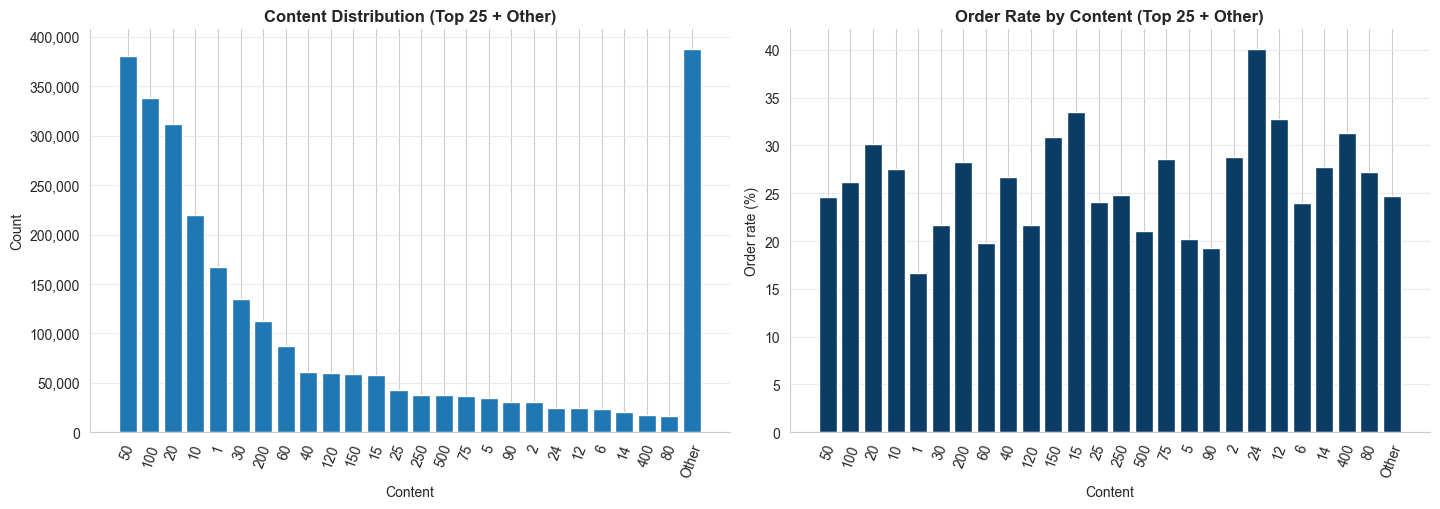

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: content
# Checks:
# - data type
# - categorical or numerical
# - unique values count from items.csv
# - missing values count from items.csv and train.csv separately
# - outliers
# - distribution
# - order rate
# - how many values from items.csv are not represented in merged dataset
# ============================================================

attr_candidates = ["content", "Content"]
display_name = "Content"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS
primary_color = viz.get("primary", "#4c78a8")
primary_dark_color = viz.get("primary_dark", "#2f5597")
grid_color = viz.get("grid", "#d0d0d0")

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
    train_missing_count = int(src_df[attr].isna().sum())
    train_missing_context = "directly in train.csv"
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge content: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr
    train_missing_count = int(work_df[attr].isna().sum())
    train_missing_context = "after merge by pid"

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce").fillna(0)

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()

is_numeric_attr = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
attr_nature = "numerical" if is_numeric_attr else "categorical"

# Source-level checks requested by user
items_attr_series = items_df[attr]
items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
items_missing_count = int(items_attr_series.isna().sum())

item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
not_represented_values = sorted(item_values_set - merged_values_set)
not_represented_count = len(not_represented_values)

missing_count = int(attr_series.isna().sum())
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""

# Outlier check + branch-specific distribution/order-rate preparation
if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()

    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100) if len(numeric_values) else 0.0
        outlier_tbl = pd.DataFrame(
            {
                "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
                "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
            }
        )
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()

        n_unique_numeric = int(numeric_values.nunique())

        if n_unique_numeric <= 20:
            dist_tbl = (
                pd.DataFrame({"value": numeric_values})
                .groupby("value", as_index=False)
                .size()
                .rename(columns={"size": "count"})
                .sort_values("value")
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)
            dist_tbl["value_label"] = dist_tbl["value"].map(lambda v: f"{v:g}")

            numeric_work = pd.DataFrame(
                {
                    "value": pd.to_numeric(work[attr], errors="coerce"),
                    "order": work["order"],
                }
            ).dropna(subset=["value"])

            order_rate_tbl = (
                numeric_work.groupby("value", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"))
                .sort_values("value")
            )
            order_rate_tbl["bin"] = order_rate_tbl["value"].map(lambda v: f"{v:g}")
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

        else:
            x_min = float(numeric_values.min())
            x_max = float(numeric_values.max())
            if x_max == x_min:
                bin_edges = np.array([x_min, x_min + 1.0], dtype=float)
            else:
                iqr_spread = float(numeric_values.quantile(0.75) - numeric_values.quantile(0.25))
                n = len(numeric_values)
                if iqr_spread > 0 and n > 1:
                    bw = 2 * iqr_spread / (n ** (1 / 3))
                    bin_count = int(np.ceil((x_max - x_min) / bw)) if bw > 0 else 30
                else:
                    bin_count = min(30, max(10, int(np.sqrt(n))))
                bin_count = max(10, min(60, bin_count))
                bin_edges = np.linspace(x_min, x_max, bin_count + 1)

            counts, edges = np.histogram(numeric_values, bins=bin_edges)
            dist_tbl = pd.DataFrame(
                {
                    "bin_left": edges[:-1],
                    "bin_right": edges[1:],
                    "count": counts,
                }
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

            numeric_work = pd.DataFrame(
                {
                    "value": pd.to_numeric(work[attr], errors="coerce"),
                    "order": work["order"],
                }
            ).dropna(subset=["value"])
            q_bins = int(min(10, max(2, int(numeric_work["value"].nunique()))))
            try:
                numeric_work["bin"] = pd.qcut(numeric_work["value"], q=q_bins, duplicates="drop")
            except ValueError:
                numeric_work["bin"] = pd.cut(numeric_work["value"], bins=q_bins, include_lowest=True)

            order_rate_tbl = (
                numeric_work.groupby("bin", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"), avg_content=("value", "mean"))
                .sort_values("avg_content")
            )
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
            order_rate_tbl["bin"] = order_rate_tbl["bin"].astype("string")

    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
        dist_tbl = pd.DataFrame(columns=["value", "count", "share_pct", "value_label"])
        order_rate_tbl = pd.DataFrame(columns=["bin", "total_events", "orders", "order_rate", "order_rate_pct"])

else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)
    rare_threshold_abs = max(10, int(len(work) * 0.001))
    rare_levels = level_counts[level_counts <= rare_threshold_abs]
    outlier_count = int(len(rare_levels))
    outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
    outlier_tbl = (
        rare_levels.rename_axis(attr)
        .reset_index(name="count")
        .assign(outlier_rule=f"rare_level_count_le_{rare_threshold_abs}")
    )
    outlier_preview = rare_levels.head(10).index.tolist()

    dist_tbl = (
        display_attr.value_counts(dropna=False)
        .rename_axis(attr)
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

    order_rate_tbl = (
        pd.DataFrame({attr: display_attr, "order": work["order"]})
        .groupby(attr, as_index=False)
        .agg(total_events=("order", "size"), orders=("order", "sum"))
    )
    order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
    order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
    order_rate_tbl = order_rate_tbl.sort_values("total_events", ascending=False)

# Console checks
print("=== content Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in items.csv: {items_missing_count:,}")
print(f"Missing values count in train.csv ({train_missing_context}): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
print(f"content values in items.csv not represented in merged dataset: {not_represented_count:,}")
if not_represented_values:
    sample_n = min(12, len(not_represented_values))
    print(f"Not represented values preview: {not_represented_values[:sample_n]}")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
else:
    print(f"Outliers (rare levels): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "content_distribution.csv"
order_rate_out = processed_dir / "content_order_rate.csv"
outlier_out = processed_dir / "content_outlier_report.csv"
not_represented_out = processed_dir / "content_not_represented_in_merged.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
pd.DataFrame({attr: not_represented_values}).to_csv(not_represented_out, index=False)

# Plot distribution and order rate
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

if is_numeric_attr:
    if "value_label" in dist_tbl.columns and len(dist_tbl) > 0:
        axes[0].bar(dist_tbl["value_label"].astype(str), dist_tbl["count"], color=primary_color, alpha=0.9)
        axes[0].set_title(f"{display_name} Distribution by Value")
        axes[0].set_xlabel(f"{display_name} value")
    else:
        if len(dist_tbl) > 0:
            bin_centers = (dist_tbl["bin_left"] + dist_tbl["bin_right"]) / 2
            bin_width = (dist_tbl["bin_right"] - dist_tbl["bin_left"]).median() if len(dist_tbl) > 1 else 1.0
            axes[0].bar(bin_centers, dist_tbl["count"], width=bin_width * 0.95, color=primary_color, alpha=0.9)
        axes[0].set_title(f"{display_name} Distribution (Histogram)")
        axes[0].set_xlabel(display_name)

    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    if len(order_rate_tbl) > 0:
        axes[1].bar(order_rate_tbl["bin"].astype(str), order_rate_tbl["order_rate_pct"], color=primary_dark_color, alpha=0.9)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(f"{display_name} group")
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

else:
    top_n = 25
    dist_plot = dist_tbl.head(top_n).copy()
    if len(dist_tbl) > top_n:
        other_count = int(dist_tbl.iloc[top_n:]["count"].sum())
        dist_plot = pd.concat(
            [
                dist_plot,
                pd.DataFrame({attr: ["Other"], "count": [other_count], "share_pct": [round(other_count / dist_tbl["count"].sum() * 100, 2)]}),
            ],
            ignore_index=True,
        )

    selected_levels = dist_plot[attr].astype("string").tolist()
    if "Other" in selected_levels:
        selected_levels_no_other = [x for x in selected_levels if x != "Other"]
        order_subset = order_rate_tbl[order_rate_tbl[attr].astype("string").isin(selected_levels_no_other)].copy()
        if len(order_rate_tbl) > len(order_subset):
            other_total_events = int(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "total_events"].sum())
            other_orders = float(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "orders"].sum())
            other_rate = (other_orders / other_total_events) if other_total_events > 0 else np.nan
            order_subset = pd.concat(
                [
                    order_subset,
                    pd.DataFrame(
                        {
                            attr: ["Other"],
                            "total_events": [other_total_events],
                            "orders": [other_orders],
                            "order_rate": [other_rate],
                            "order_rate_pct": [round(other_rate * 100, 2) if pd.notna(other_rate) else np.nan],
                        }
                    ),
                ],
                ignore_index=True,
            )
        order_plot = order_subset.set_index(attr).reindex(selected_levels).reset_index()
    else:
        order_plot = order_rate_tbl.head(top_n).copy()

    axes[0].bar(dist_plot[attr].astype(str), dist_plot["count"], color=primary_color)
    axes[0].set_title(f"{display_name} Distribution")
    axes[0].set_xlabel(display_name)
    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].tick_params(axis="x", rotation=70)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].bar(order_plot[attr].astype(str), order_plot["order_rate_pct"], color=primary_dark_color)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(display_name)
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=70)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "content_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig)

***unit***

=== unit Output Check ===
Data type: str
Attribute nature: categorical
Unique values count in items.csv (non-missing): 8
Unique values count in items.csv (including missing label): 8
Unique values count in merged event dataset: 8
Unique values preview (merged): ['CM', 'G', 'KG', 'L', 'M', 'ML', 'P', 'ST']
Missing values count in items.csv: 0
Missing values count in train.csv (after merge by pid): 0
Missing values in merged event dataset: 0 (0.00%)
unit values in items.csv not represented in merged dataset: 0
Outliers (rare levels): 4 (50.00% of non-missing levels)
Outlier preview: ['L', 'M', 'CM', 'KG']
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/unit_distribution_order_rate.png
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/unit_distribution.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project/data/processed/unit_order_rate.csv
Saved table to: /Users/annageiser/Documents/GitHub/analytics-project

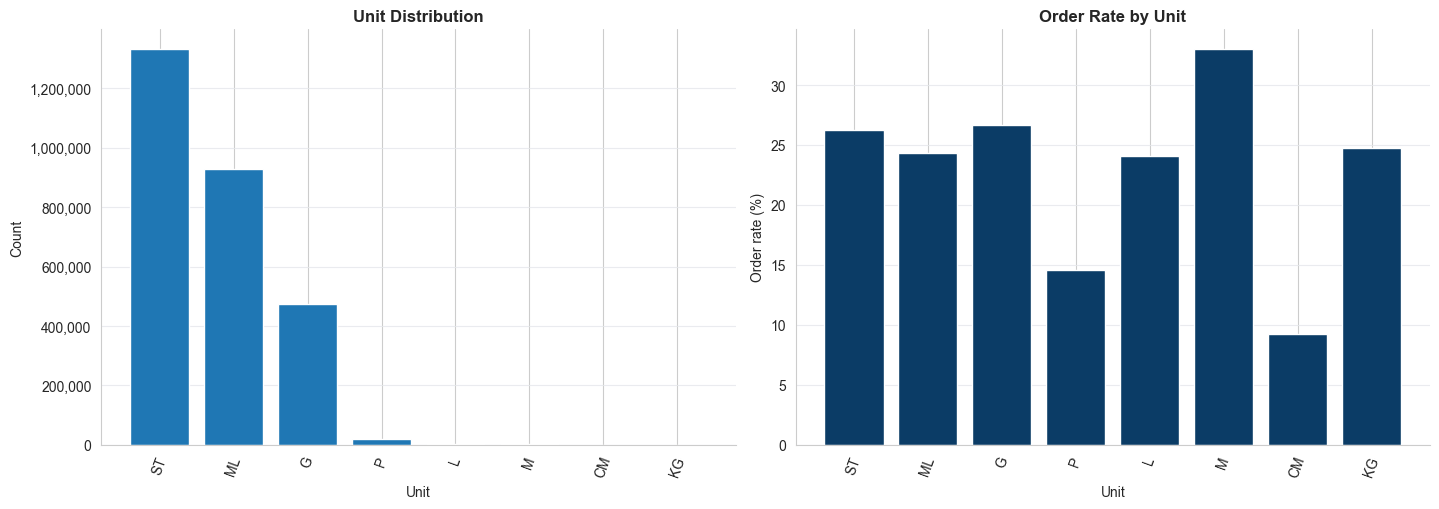

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: unit
# Checks:
# - data type
# - categorical or numerical
# - unique values count from items.csv
# - missing values count from items.csv and train.csv separately
# - outliers
# - distribution
# - order rate
# - how many values from items.csv are not represented in merged dataset
# ============================================================

attr_candidates = ["unit", "Unit"]
display_name = "Unit"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS
primary_color = viz.get("primary", "#4c78a8")
primary_dark_color = viz.get("primary_dark", "#2f5597")
grid_color = viz.get("grid", "#d0d0d0")

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
    train_missing_count = int(src_df[attr].isna().sum())
    train_missing_context = "directly in train.csv"
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge unit: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr
    train_missing_count = int(work_df[attr].isna().sum())
    train_missing_context = "after merge by pid"

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce").fillna(0)

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()

is_numeric_attr = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
attr_nature = "numerical" if is_numeric_attr else "categorical"

# Source-level checks requested by user
items_attr_series = items_df[attr]
items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
items_missing_count = int(items_attr_series.isna().sum())

item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
not_represented_values = sorted(item_values_set - merged_values_set)
not_represented_count = len(not_represented_values)

missing_count = int(attr_series.isna().sum())
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""

# Outlier check + branch-specific distribution/order-rate preparation
if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()

    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100) if len(numeric_values) else 0.0
        outlier_tbl = pd.DataFrame(
            {
                "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
                "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
            }
        )
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()

        n_unique_numeric = int(numeric_values.nunique())

        if n_unique_numeric <= 20:
            dist_tbl = (
                pd.DataFrame({"value": numeric_values})
                .groupby("value", as_index=False)
                .size()
                .rename(columns={"size": "count"})
                .sort_values("value")
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)
            dist_tbl["value_label"] = dist_tbl["value"].map(lambda v: f"{v:g}")

            numeric_work = pd.DataFrame(
                {
                    "value": pd.to_numeric(work[attr], errors="coerce"),
                    "order": work["order"],
                }
            ).dropna(subset=["value"])

            order_rate_tbl = (
                numeric_work.groupby("value", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"))
                .sort_values("value")
            )
            order_rate_tbl["bin"] = order_rate_tbl["value"].map(lambda v: f"{v:g}")
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

        else:
            x_min = float(numeric_values.min())
            x_max = float(numeric_values.max())
            if x_max == x_min:
                bin_edges = np.array([x_min, x_min + 1.0], dtype=float)
            else:
                iqr_spread = float(numeric_values.quantile(0.75) - numeric_values.quantile(0.25))
                n = len(numeric_values)
                if iqr_spread > 0 and n > 1:
                    bw = 2 * iqr_spread / (n ** (1 / 3))
                    bin_count = int(np.ceil((x_max - x_min) / bw)) if bw > 0 else 30
                else:
                    bin_count = min(30, max(10, int(np.sqrt(n))))
                bin_count = max(10, min(60, bin_count))
                bin_edges = np.linspace(x_min, x_max, bin_count + 1)

            counts, edges = np.histogram(numeric_values, bins=bin_edges)
            dist_tbl = pd.DataFrame(
                {
                    "bin_left": edges[:-1],
                    "bin_right": edges[1:],
                    "count": counts,
                }
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

            numeric_work = pd.DataFrame(
                {
                    "value": pd.to_numeric(work[attr], errors="coerce"),
                    "order": work["order"],
                }
            ).dropna(subset=["value"])
            q_bins = int(min(10, max(2, int(numeric_work["value"].nunique()))))
            try:
                numeric_work["bin"] = pd.qcut(numeric_work["value"], q=q_bins, duplicates="drop")
            except ValueError:
                numeric_work["bin"] = pd.cut(numeric_work["value"], bins=q_bins, include_lowest=True)

            order_rate_tbl = (
                numeric_work.groupby("bin", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"), avg_unit=("value", "mean"))
                .sort_values("avg_unit")
            )
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
            order_rate_tbl["bin"] = order_rate_tbl["bin"].astype("string")

    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
        dist_tbl = pd.DataFrame(columns=["value", "count", "share_pct", "value_label"])
        order_rate_tbl = pd.DataFrame(columns=["bin", "total_events", "orders", "order_rate", "order_rate_pct"])

else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)
    rare_threshold_abs = max(10, int(len(work) * 0.001))
    rare_levels = level_counts[level_counts <= rare_threshold_abs]
    outlier_count = int(len(rare_levels))
    outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
    outlier_tbl = (
        rare_levels.rename_axis(attr)
        .reset_index(name="count")
        .assign(outlier_rule=f"rare_level_count_le_{rare_threshold_abs}")
    )
    outlier_preview = rare_levels.head(10).index.tolist()

    dist_tbl = (
        display_attr.value_counts(dropna=False)
        .rename_axis(attr)
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

    order_rate_tbl = (
        pd.DataFrame({attr: display_attr, "order": work["order"]})
        .groupby(attr, as_index=False)
        .agg(total_events=("order", "size"), orders=("order", "sum"))
    )
    order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
    order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
    order_rate_tbl = order_rate_tbl.sort_values("total_events", ascending=False)

# Console checks
print("=== unit Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in items.csv: {items_missing_count:,}")
print(f"Missing values count in train.csv ({train_missing_context}): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
print(f"unit values in items.csv not represented in merged dataset: {not_represented_count:,}")
if not_represented_values:
    sample_n = min(12, len(not_represented_values))
    print(f"Not represented values preview: {not_represented_values[:sample_n]}")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
else:
    print(f"Outliers (rare levels): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "unit_distribution.csv"
order_rate_out = processed_dir / "unit_order_rate.csv"
outlier_out = processed_dir / "unit_outlier_report.csv"
not_represented_out = processed_dir / "unit_not_represented_in_merged.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
pd.DataFrame({attr: not_represented_values}).to_csv(not_represented_out, index=False)

# Plot distribution and order rate
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

if is_numeric_attr:
    if "value_label" in dist_tbl.columns and len(dist_tbl) > 0:
        axes[0].bar(dist_tbl["value_label"].astype(str), dist_tbl["count"], color=primary_color, alpha=0.9)
        axes[0].set_title(f"{display_name} Distribution by Value")
        axes[0].set_xlabel(f"{display_name} value")
    else:
        if len(dist_tbl) > 0:
            bin_centers = (dist_tbl["bin_left"] + dist_tbl["bin_right"]) / 2
            bin_width = (dist_tbl["bin_right"] - dist_tbl["bin_left"]).median() if len(dist_tbl) > 1 else 1.0
            axes[0].bar(bin_centers, dist_tbl["count"], width=bin_width * 0.95, color=primary_color, alpha=0.9)
        axes[0].set_title(f"{display_name} Distribution (Histogram)")
        axes[0].set_xlabel(display_name)

    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    if len(order_rate_tbl) > 0:
        axes[1].bar(order_rate_tbl["bin"].astype(str), order_rate_tbl["order_rate_pct"], color=primary_dark_color, alpha=0.9)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(f"{display_name} group")
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

else:
    top_n = 25
    dist_plot = dist_tbl.head(top_n).copy()
    if len(dist_tbl) > top_n:
        other_count = int(dist_tbl.iloc[top_n:]["count"].sum())
        dist_plot = pd.concat(
            [
                dist_plot,
                pd.DataFrame({attr: ["Other"], "count": [other_count], "share_pct": [round(other_count / dist_tbl["count"].sum() * 100, 2)]}),
            ],
            ignore_index=True,
        )

    selected_levels = dist_plot[attr].astype("string").tolist()
    if "Other" in selected_levels:
        selected_levels_no_other = [x for x in selected_levels if x != "Other"]
        order_subset = order_rate_tbl[order_rate_tbl[attr].astype("string").isin(selected_levels_no_other)].copy()
        if len(order_rate_tbl) > len(order_subset):
            other_total_events = int(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "total_events"].sum())
            other_orders = float(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "orders"].sum())
            other_rate = (other_orders / other_total_events) if other_total_events > 0 else np.nan
            order_subset = pd.concat(
                [
                    order_subset,
                    pd.DataFrame(
                        {
                            attr: ["Other"],
                            "total_events": [other_total_events],
                            "orders": [other_orders],
                            "order_rate": [other_rate],
                            "order_rate_pct": [round(other_rate * 100, 2) if pd.notna(other_rate) else np.nan],
                        }
                    ),
                ],
                ignore_index=True,
            )
        order_plot = order_subset.set_index(attr).reindex(selected_levels).reset_index()
    else:
        order_plot = order_rate_tbl.head(top_n).copy()

    axes[0].bar(dist_plot[attr].astype(str), dist_plot["count"], color=primary_color)
    axes[0].set_title(f"{display_name} Distribution")
    axes[0].set_xlabel(display_name)
    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].tick_params(axis="x", rotation=70)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].bar(order_plot[attr].astype(str), order_plot["order_rate_pct"], color=primary_dark_color)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(display_name)
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=70)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "unit_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig)

***revenue***

=== revenue Output Check ===
Data type: float64
Attribute nature: numerical
Attribute not found in items.csv; item-level unique/missing/coverage checks are N/A.
Unique values count in merged event dataset: 7,520
Unique values preview (merged): ['0.0', '0.07', '0.08', '0.14', '0.16', '0.18', '0.21', '0.24', '0.25', '0.26', '0.28', '0.3'] ...
Missing values count in train.csv (directly in train.csv): 0
Missing values in merged event dataset: 0 (0.00%)
revenue values in items.csv not represented in merged dataset: N/A (attribute absent in items.csv)
Outliers (IQR 1.5 rule): 587,133 (21.30% of non-missing)
Revenue = 0: share=74.42% | order_rate=0.00%
Revenue > 0: share=25.58% | order_rate=100.00%
Outlier preview: [6.55, 10.03, 19.71, 19.15, 54.95, 9.04, 6.0, 79.05, 16.4, 7.65]
Daily revenue aggregation points: 92
Total revenue across aggregated days: 10,337,709.63
Final cumulative revenue (event-added): 10,337,709.63
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/fig

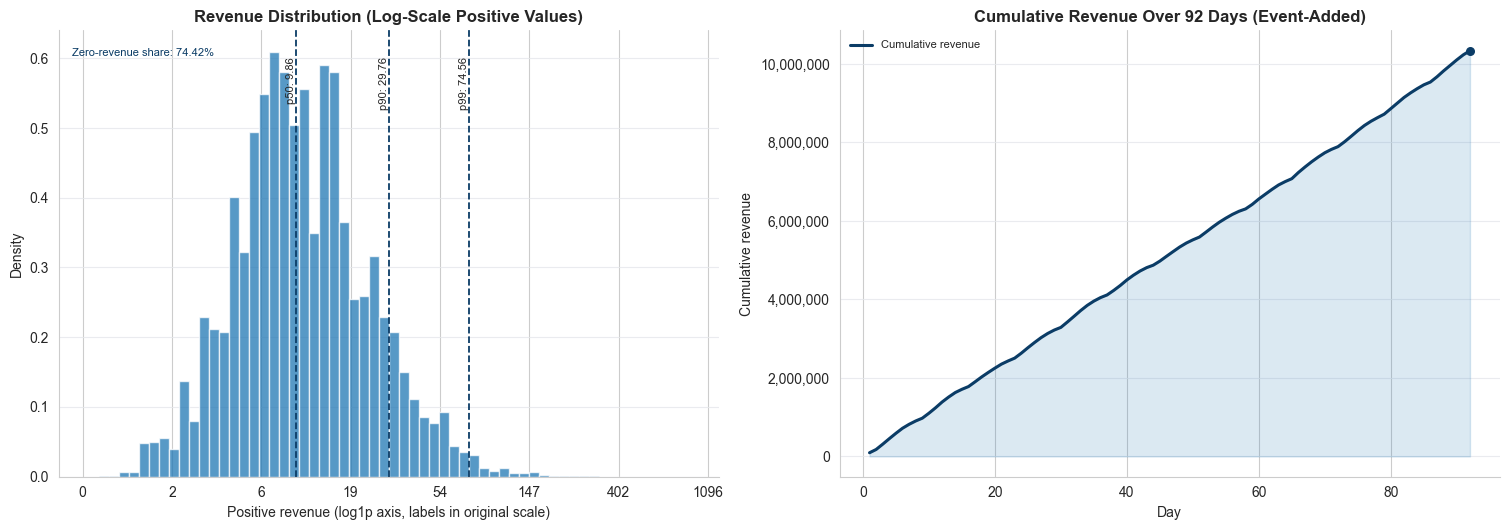

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: revenue
# Checks:
# - data type
# - categorical or numerical
# - unique values count from items.csv
# - missing values count from items.csv and train.csv separately
# - outliers
# - distribution
# - order rate
# - how many values from items.csv are not represented in merged dataset
# ============================================================

attr_candidates = ["revenue", "Revenue"]
display_name = "Revenue"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS
primary_color = viz.get("primary", "#4c78a8")
primary_dark_color = viz.get("primary_dark", "#2f5597")
grid_color = viz.get("grid", "#d0d0d0")
accent_color = viz.get("accent", primary_dark_color)

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

train_attr = next((c for c in attr_candidates if c in src_df.columns), None)
items_attr = next((c for c in attr_candidates if c in items_df.columns), None)

if train_attr is None and items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in train or items data.")

if train_attr is not None:
    # revenue is train-level in this dataset
    work_df = src_df.copy()
    attr = train_attr
    train_missing_count = int(src_df[attr].isna().sum())
    train_missing_context = "directly in train.csv"
else:
    # fallback in case this attribute is item-level only
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge revenue: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr
    train_missing_count = int(work_df[attr].isna().sum())
    train_missing_context = "after merge by pid"

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df[[attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce").fillna(0)

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()

is_numeric_attr = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
attr_nature = "numerical" if is_numeric_attr else "categorical"

items_attr_available = items_attr is not None
if items_attr_available:
    items_attr_series = items_df[items_attr]
    items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
    items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
    items_missing_count = int(items_attr_series.isna().sum())

    item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
    merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
    not_represented_values = sorted(item_values_set - merged_values_set)
    not_represented_count = len(not_represented_values)
else:
    items_unique_non_null_count = None
    items_unique_including_missing_count = None
    items_missing_count = None
    not_represented_values = []
    not_represented_count = 0

missing_count = int(attr_series.isna().sum())
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""

if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()

    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100)
        outlier_tbl = pd.DataFrame(
            {
                "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
                "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
            }
        )
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()

        numeric_work = pd.DataFrame(
            {
                "value": pd.to_numeric(work[attr], errors="coerce"),
                "order": work["order"],
            }
        ).dropna(subset=["value"])

        n_unique_numeric = int(numeric_work["value"].nunique())

        # Keep a distribution table for full numeric range.
        if n_unique_numeric <= 20:
            dist_tbl = (
                numeric_work.groupby("value", as_index=False)
                .agg(count=("order", "size"))
                .sort_values("value")
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)
            dist_tbl["value_label"] = dist_tbl["value"].map(lambda v: f"{v:g}")
        else:
            x_min = float(numeric_values.min())
            x_max = float(numeric_values.max())
            if x_max == x_min:
                edges = np.array([x_min, x_min + 1.0], dtype=float)
            else:
                edges = np.linspace(x_min, x_max, 31)
            counts, edges = np.histogram(numeric_values, bins=edges)
            dist_tbl = pd.DataFrame({"bin_left": edges[:-1], "bin_right": edges[1:], "count": counts})
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

        # Keep order-rate summary (zero vs positive) in output tables.
        revenue_state = np.where(numeric_work["value"] > 0, "Revenue > 0", "Revenue = 0")
        order_rate_tbl = (
            pd.DataFrame({"revenue_state": revenue_state, "order": numeric_work["order"]})
            .groupby("revenue_state", as_index=False)
            .agg(total_events=("order", "size"), orders=("order", "sum"))
        )
        order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
        order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
        order_rate_tbl["share_pct"] = (order_rate_tbl["total_events"] / order_rate_tbl["total_events"].sum() * 100).round(2)
        order_rate_tbl["state_order"] = order_rate_tbl["revenue_state"].map({"Revenue = 0": 0, "Revenue > 0": 1}).fillna(99)
        order_rate_tbl = order_rate_tbl.sort_values("state_order").drop(columns=["state_order"])

        positive_values = numeric_work.loc[numeric_work["value"] > 0, "value"]
        if len(positive_values) > 0:
            positive_quantiles_tbl = pd.DataFrame(
                {
                    "quantile": [0.5, 0.9, 0.95, 0.99],
                    "value": [
                        float(positive_values.quantile(0.5)),
                        float(positive_values.quantile(0.9)),
                        float(positive_values.quantile(0.95)),
                        float(positive_values.quantile(0.99)),
                    ],
                }
            )
        else:
            positive_quantiles_tbl = pd.DataFrame(columns=["quantile", "value"])
    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
        dist_tbl = pd.DataFrame(columns=["value", "count", "share_pct", "value_label"])
        order_rate_tbl = pd.DataFrame(columns=["revenue_state", "total_events", "orders", "order_rate", "order_rate_pct", "share_pct"])
        positive_values = pd.Series(dtype=float)
        positive_quantiles_tbl = pd.DataFrame(columns=["quantile", "value"])
else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)
    rare_threshold_abs = max(10, int(len(work) * 0.001))
    rare_levels = level_counts[level_counts <= rare_threshold_abs]
    outlier_count = int(len(rare_levels))
    outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
    outlier_tbl = (
        rare_levels.rename_axis(attr)
        .reset_index(name="count")
        .assign(outlier_rule=f"rare_level_count_le_{rare_threshold_abs}")
    )
    outlier_preview = rare_levels.head(10).index.tolist()

    dist_tbl = (
        display_attr.value_counts(dropna=False)
        .rename_axis(attr)
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

    order_rate_tbl = (
        pd.DataFrame({attr: display_attr, "order": work["order"]})
        .groupby(attr, as_index=False)
        .agg(total_events=("order", "size"), orders=("order", "sum"))
        .sort_values("total_events", ascending=False)
    )
    order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
    order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
    positive_values = pd.Series(dtype=float)
    positive_quantiles_tbl = pd.DataFrame(columns=["quantile", "value"])

# Aggregate revenue over day by adding revenue event-by-event.
daily_revenue_tbl = pd.DataFrame(columns=["day", "total_revenue", "avg_revenue", "event_count", "cumulative_revenue"])
if is_numeric_attr and "day" in work_df.columns:
    lineid_candidates = ["lineID", "lineid", "line_id", "LineID"]
    line_id_col = next((c for c in lineid_candidates if c in work_df.columns), None)

    day_frame = pd.DataFrame(
        {
            "day": pd.to_numeric(work_df["day"], errors="coerce"),
            "revenue": pd.to_numeric(work_df[attr], errors="coerce").fillna(0),
        }
    )
    if line_id_col is not None:
        day_frame["line_order"] = pd.to_numeric(work_df[line_id_col], errors="coerce")
    else:
        day_frame["line_order"] = np.arange(len(day_frame), dtype=float)

    day_frame = day_frame.dropna(subset=["day"]).copy()

    if len(day_frame) > 0:
        day_frame["day"] = day_frame["day"].astype(int)
        fallback_order = pd.Series(np.arange(len(day_frame), dtype=float), index=day_frame.index)
        day_frame["line_order"] = day_frame["line_order"].fillna(fallback_order)
        day_frame = day_frame.sort_values(["day", "line_order"]).reset_index(drop=True)
        day_frame["event_idx"] = np.arange(1, len(day_frame) + 1, dtype=int)
        day_frame["cumulative_revenue_event"] = day_frame["revenue"].cumsum()

        daily_revenue_tbl = (
            day_frame.groupby("day", as_index=False)
            .agg(
                total_revenue=("revenue", "sum"),
                avg_revenue=("revenue", "mean"),
                event_count=("revenue", "size"),
                cumulative_revenue=("cumulative_revenue_event", "max"),
            )
            .sort_values("day")
        )

        if daily_revenue_tbl["day"].min() >= 1 and daily_revenue_tbl["day"].max() <= 92:
            full_days = pd.DataFrame({"day": np.arange(1, 93, dtype=int)})
            daily_revenue_tbl = full_days.merge(daily_revenue_tbl, on="day", how="left")
            daily_revenue_tbl[["total_revenue", "avg_revenue", "event_count"]] = daily_revenue_tbl[["total_revenue", "avg_revenue", "event_count"]].fillna(0)

        daily_revenue_tbl["event_count"] = daily_revenue_tbl["event_count"].astype(int)
        daily_revenue_tbl["cumulative_revenue"] = daily_revenue_tbl["total_revenue"].cumsum()

print("=== revenue Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
if items_attr_available:
    print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
    print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
    print(f"Missing values count in items.csv: {items_missing_count:,}")
else:
    print("Attribute not found in items.csv; item-level unique/missing/coverage checks are N/A.")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in train.csv ({train_missing_context}): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
if items_attr_available:
    print(f"revenue values in items.csv not represented in merged dataset: {not_represented_count:,}")
    if not_represented_values:
        sample_n = min(12, len(not_represented_values))
        print(f"Not represented values preview: {not_represented_values[:sample_n]}")
else:
    print("revenue values in items.csv not represented in merged dataset: N/A (attribute absent in items.csv)")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
    if len(order_rate_tbl) > 0 and "revenue_state" in order_rate_tbl.columns:
        for _, row in order_rate_tbl.iterrows():
            print(f"{row['revenue_state']}: share={row['share_pct']:.2f}% | order_rate={row['order_rate_pct']:.2f}%")
else:
    print(f"Outliers (rare levels): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")
if len(daily_revenue_tbl) > 0:
    print(f"Daily revenue aggregation points: {len(daily_revenue_tbl):,}")
    print(f"Total revenue across aggregated days: {daily_revenue_tbl['total_revenue'].sum():,.2f}")
    print(f"Final cumulative revenue (event-added): {daily_revenue_tbl['cumulative_revenue'].iloc[-1]:,.2f}")
else:
    print("Daily revenue aggregation over day: unavailable (day column missing or invalid).")

processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "revenue_distribution.csv"
order_rate_out = processed_dir / "revenue_order_rate.csv"
outlier_out = processed_dir / "revenue_outlier_report.csv"
not_represented_out = processed_dir / "revenue_not_represented_in_merged.csv"
positive_quantiles_out = processed_dir / "revenue_positive_quantiles.csv"
daily_revenue_out = processed_dir / "revenue_daily_92day.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
positive_quantiles_tbl.to_csv(positive_quantiles_out, index=False)
daily_revenue_tbl.to_csv(daily_revenue_out, index=False)
if items_attr_available:
    pd.DataFrame({items_attr: not_represented_values}).to_csv(not_represented_out, index=False)
else:
    pd.DataFrame(columns=[attr]).to_csv(not_represented_out, index=False)

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.4))

if is_numeric_attr:
    # Left: better-fitting view for skewed revenue with log-scale positive values.
    if len(numeric_values) > 0:
        positive_plot = numeric_values[numeric_values > 0]
        zero_share_pct = (numeric_values <= 0).mean() * 100

        if len(positive_plot) > 0:
            log_positive = np.log1p(positive_plot.to_numpy(dtype=float))
            n_bins = int(min(60, max(25, np.sqrt(len(log_positive)))))
            axes[0].hist(log_positive, bins=n_bins, density=True, color=primary_color, alpha=0.75)

            q_specs = [(0.5, "p50"), (0.9, "p90"), (0.99, "p99")]
            for q, label in q_specs:
                q_val = float(np.quantile(positive_plot, q))
                q_log = np.log1p(q_val)
                axes[0].axvline(q_log, color=primary_dark_color, linestyle="--", linewidth=1.3)
                axes[0].text(
                    q_log,
                    axes[0].get_ylim()[1] * 0.94,
                    f"{label}: {q_val:.2f}",
                    rotation=90,
                    va="top",
                    ha="right",
                    fontsize=8,
                )

            axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{np.expm1(v):.0f}"))
            axes[0].set_xlabel("Positive revenue (log1p axis, labels in original scale)")
            axes[0].set_title("Revenue Distribution (Log-Scale Positive Values)")
            axes[0].set_ylabel("Density")
            axes[0].text(
                0.02,
                0.96,
                f"Zero-revenue share: {zero_share_pct:.2f}%",
                transform=axes[0].transAxes,
                ha="left",
                va="top",
                fontsize=8,
                color=primary_dark_color,
            )
        else:
            axes[0].text(0.5, 0.5, "No positive revenue values", ha="center", va="center", transform=axes[0].transAxes)
            axes[0].set_title("Revenue Distribution (Log-Scale Positive Values)")
            axes[0].set_xlabel("Positive revenue")
            axes[0].set_ylabel("Density")
    else:
        axes[0].text(0.5, 0.5, "No revenue values", ha="center", va="center", transform=axes[0].transAxes)
        axes[0].set_title("Revenue Distribution (Log-Scale Positive Values)")
        axes[0].set_xlabel("Revenue")
        axes[0].set_ylabel("Density")

    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    # Right: cumulative revenue from event-by-event addition across days.
    if len(daily_revenue_tbl) > 0:
        axes[1].plot(
            daily_revenue_tbl["day"],
            daily_revenue_tbl["cumulative_revenue"],
            color=primary_dark_color,
            linewidth=2.2,
            label="Cumulative revenue",
        )
        axes[1].fill_between(
            daily_revenue_tbl["day"],
            daily_revenue_tbl["cumulative_revenue"],
            color=primary_color,
            alpha=0.16,
        )

        final_day = int(daily_revenue_tbl["day"].iloc[-1])
        final_cum = float(daily_revenue_tbl["cumulative_revenue"].iloc[-1])
        axes[1].scatter([final_day], [final_cum], color=accent_color, s=30, zorder=3)

        axes[1].set_title("Cumulative Revenue Over 92 Days (Event-Added)")
        axes[1].set_xlabel("Day")
        axes[1].set_ylabel("Cumulative revenue")
        axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
        axes[1].legend(frameon=False, fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "No day data available", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Cumulative Revenue Over 92 Days (Event-Added)")
        axes[1].set_xlabel("Day")
        axes[1].set_ylabel("Cumulative revenue")

    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
else:
    top_n = 25
    dist_plot = dist_tbl.head(top_n).copy()
    if len(dist_tbl) > top_n:
        other_count = int(dist_tbl.iloc[top_n:]["count"].sum())
        dist_plot = pd.concat(
            [
                dist_plot,
                pd.DataFrame({attr: ["Other"], "count": [other_count], "share_pct": [round(other_count / dist_tbl["count"].sum() * 100, 2)]}),
            ],
            ignore_index=True,
        )

    selected_levels = dist_plot[attr].astype("string").tolist()
    if "Other" in selected_levels:
        selected_no_other = [x for x in selected_levels if x != "Other"]
        order_subset = order_rate_tbl[order_rate_tbl[attr].astype("string").isin(selected_no_other)].copy()
        if len(order_rate_tbl) > len(order_subset):
            other_total_events = int(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_no_other), "total_events"].sum())
            other_orders = float(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_no_other), "orders"].sum())
            other_rate = (other_orders / other_total_events) if other_total_events > 0 else np.nan
            order_subset = pd.concat(
                [
                    order_subset,
                    pd.DataFrame(
                        {
                            attr: ["Other"],
                            "total_events": [other_total_events],
                            "orders": [other_orders],
                            "order_rate": [other_rate],
                            "order_rate_pct": [round(other_rate * 100, 2) if pd.notna(other_rate) else np.nan],
                        }
                    ),
                ],
                ignore_index=True,
            )
        order_plot = order_subset.set_index(attr).reindex(selected_levels).reset_index()
    else:
        order_plot = order_rate_tbl.head(top_n).copy()

    axes[0].bar(dist_plot[attr].astype(str), dist_plot["count"], color=primary_color)
    axes[0].set_title(f"{display_name} Distribution")
    axes[0].set_xlabel(display_name)
    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].tick_params(axis="x", rotation=70)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].bar(order_plot[attr].astype(str), order_plot["order_rate_pct"], color=primary_dark_color)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(display_name)
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=70)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "revenue_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {positive_quantiles_out.resolve()}")
print(f"Saved table to: {daily_revenue_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig)

***pid***

=== pid Output Check ===
Data type: int64
Attribute nature: categorical
Unique values count in items.csv (non-missing): 22,035
Unique values count in items.csv (including missing label): 22,035
Unique values count in merged event dataset: 21,928
Unique values preview (merged): ['1', '10', '100', '1000', '10000', '10001', '10002', '10003', '10004', '10005', '10006', '10007'] ...
Missing values count in items.csv: 0
Missing values count in train.csv (directly in train.csv): 0
Missing values in merged event dataset: 0 (0.00%)
pid values in items.csv not represented in merged dataset: 107
Not represented values preview: ['10133', '10195', '10222', '10226', '10852', '1093', '11234', '11439', '11465', '11946', '12262', '12335']
Outliers (frequency IQR rule): 2,633 (12.01% of non-missing levels)
Outlier preview: ['2655', '2491', '16641', '16144', '7403', '3853', '1426', '1247', '1037', '1567']
Saved figure to: /Users/annageiser/Documents/GitHub/analytics-project/figures/pid_distribution_order

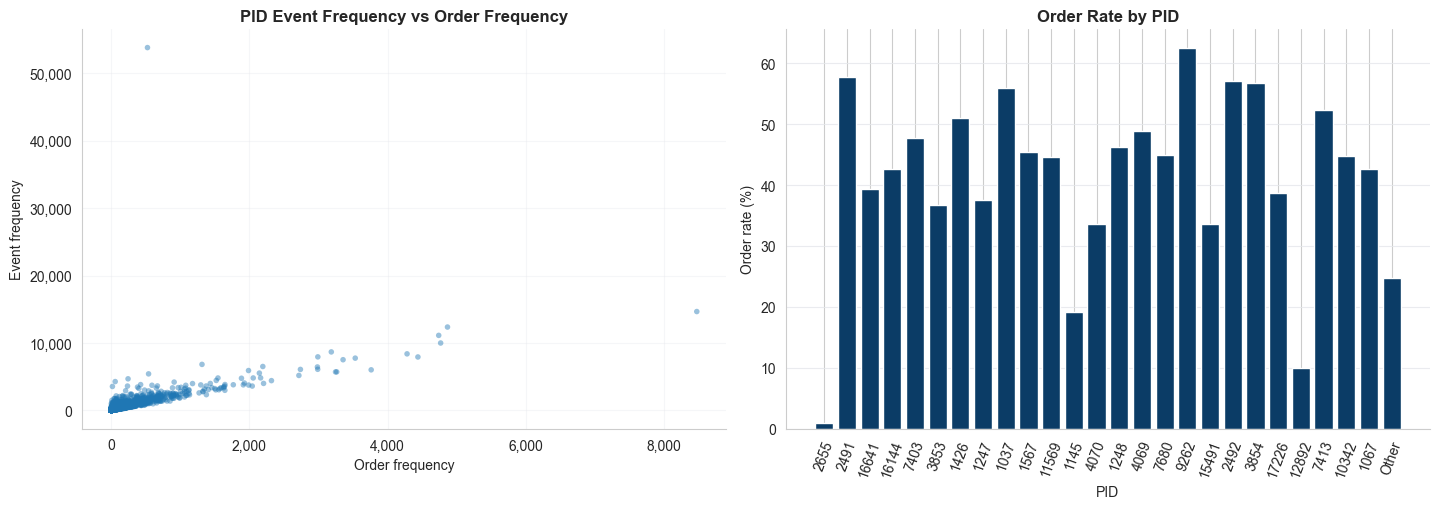

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# ============================================================
# Data Analysis: pid
# Checks:
# - data type
# - categorical or numerical
# - unique values count from items.csv
# - missing values count from items.csv and train.csv separately
# - outliers
# - distribution
# - order rate
# - how many values from items.csv are not represented in merged dataset
# ============================================================

attr_candidates = ["pid", "PID"]
display_name = "PID"

if "VIZ_COLORS" not in globals():
    raise ValueError("Global color theme VIZ_COLORS is not available. Run the setup cells first.")
viz = VIZ_COLORS
primary_color = viz.get("primary", "#4c78a8")
primary_dark_color = viz.get("primary_dark", "#2f5597")
grid_color = viz.get("grid", "#d0d0d0")

if "train_raw_df" in globals():
    src_df = train_raw_df.copy()
else:
    src_df = pd.read_csv(Path("data/train.csv"), sep="|")

if "items_raw_df" in globals():
    items_df = items_raw_df.copy()
else:
    items_df = pd.read_csv(Path("data/items.csv"), sep="|")

items_attr = next((c for c in attr_candidates if c in items_df.columns), None)
if items_attr is None:
    raise ValueError(f"None of {attr_candidates} found in items data.")

if items_attr in src_df.columns:
    work_df = src_df.copy()
    attr = items_attr
    train_missing_count = int(src_df[attr].isna().sum())
    train_missing_context = "directly in train.csv"
else:
    if "pid" not in src_df.columns:
        raise ValueError("Cannot merge pid: pid column is missing in train data.")
    work_df = src_df.merge(items_df[["pid", items_attr]], on="pid", how="left", validate="m:1")
    attr = items_attr
    train_missing_count = int(work_df[attr].isna().sum())
    train_missing_context = "after merge by pid"

required_cols = {attr, "order"}
missing_cols = sorted(required_cols - set(work_df.columns))
if missing_cols:
    raise ValueError(f"Missing required columns for {attr} analysis: {missing_cols}")

work = work_df.loc[:, [attr, "order"]].copy()
work["order"] = pd.to_numeric(work["order"], errors="coerce").fillna(0)

attr_series = work[attr]
attr_dtype = attr_series.dtype
non_null_attr = attr_series.dropna()

numeric_candidate = bool(pd.to_numeric(non_null_attr, errors="coerce").notna().all()) if len(non_null_attr) > 0 else False
identifier_like_fields = {"pid", "lineid", "line_id", "lineid"}
is_identifier_like = attr.lower() in identifier_like_fields
is_numeric_attr = bool(numeric_candidate and not is_identifier_like)
attr_nature = "numerical" if is_numeric_attr else "categorical"

# Source-level checks requested by user
items_attr_series = items_df[items_attr]
items_unique_non_null_count = int(items_attr_series.dropna().astype("string").nunique())
items_unique_including_missing_count = int(items_attr_series.astype("string").fillna("missing").nunique())
items_missing_count = int(items_attr_series.isna().sum())

item_values_set = set(items_attr_series.dropna().astype("string").unique().tolist())
merged_values_set = set(attr_series.dropna().astype("string").unique().tolist())
not_represented_values = sorted(item_values_set - merged_values_set)
not_represented_count = len(not_represented_values)

missing_count = int(attr_series.isna().sum())
missing_pct = (missing_count / len(attr_series) * 100) if len(attr_series) else 0.0

display_attr = attr_series.astype("string").fillna("missing")
unique_values = sorted(display_attr.unique().tolist())
preview_n = 12
preview_suffix = " ..." if len(unique_values) > preview_n else ""

# Outlier check + branch-specific distribution/order-rate preparation
if is_numeric_attr:
    numeric_values = pd.to_numeric(non_null_attr, errors="coerce").dropna()

    if len(numeric_values) > 0:
        q1 = float(numeric_values.quantile(0.25))
        q3 = float(numeric_values.quantile(0.75))
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_values < lower) | (numeric_values > upper)
        outlier_count = int(outlier_mask.sum())
        outlier_pct = (outlier_count / len(numeric_values) * 100) if len(numeric_values) else 0.0
        outlier_tbl = pd.DataFrame(
            {
                "metric": ["method", "q1", "q3", "iqr", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"],
                "value": ["IQR_1.5", q1, q3, iqr, lower, upper, outlier_count, round(outlier_pct, 4)],
            }
        )
        outlier_preview = numeric_values[outlier_mask].head(10).tolist()

        n_unique_numeric = int(numeric_values.nunique())

        if n_unique_numeric <= 20:
            dist_tbl = (
                pd.DataFrame({"value": numeric_values})
                .groupby("value", as_index=False)
                .size()
                .rename(columns={"size": "count"})
                .sort_values("value")
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)
            dist_tbl["value_label"] = dist_tbl["value"].map(lambda v: f"{v:g}")

            numeric_work = pd.DataFrame(
                {
                    "value": pd.to_numeric(work[attr], errors="coerce"),
                    "order": work["order"],
                }
            ).dropna(subset=["value"])

            order_rate_tbl = (
                numeric_work.groupby("value", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"))
                .sort_values("value")
            )
            order_rate_tbl["bin"] = order_rate_tbl["value"].map(lambda v: f"{v:g}")
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)

        else:
            x_min = float(numeric_values.min())
            x_max = float(numeric_values.max())
            if x_max == x_min:
                bin_edges = np.array([x_min, x_min + 1.0], dtype=float)
            else:
                iqr_spread = float(numeric_values.quantile(0.75) - numeric_values.quantile(0.25))
                n = len(numeric_values)
                if iqr_spread > 0 and n > 1:
                    bw = 2 * iqr_spread / (n ** (1 / 3))
                    bin_count = int(np.ceil((x_max - x_min) / bw)) if bw > 0 else 30
                else:
                    bin_count = min(30, max(10, int(np.sqrt(n))))
                bin_count = max(10, min(60, bin_count))
                bin_edges = np.linspace(x_min, x_max, bin_count + 1)

            counts, edges = np.histogram(numeric_values, bins=bin_edges)
            dist_tbl = pd.DataFrame(
                {
                    "bin_left": edges[:-1],
                    "bin_right": edges[1:],
                    "count": counts,
                }
            )
            dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

            numeric_work = pd.DataFrame(
                {
                    "value": pd.to_numeric(work[attr], errors="coerce"),
                    "order": work["order"],
                }
            ).dropna(subset=["value"])
            q_bins = int(min(10, max(2, int(numeric_work["value"].nunique()))))
            try:
                numeric_work["bin"] = pd.qcut(numeric_work["value"], q=q_bins, duplicates="drop")
            except ValueError:
                numeric_work["bin"] = pd.cut(numeric_work["value"], bins=q_bins, include_lowest=True)

            order_rate_tbl = (
                numeric_work.groupby("bin", as_index=False)
                .agg(total_events=("order", "size"), orders=("order", "sum"), avg_pid=("value", "mean"))
                .sort_values("avg_pid")
            )
            order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
            order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
            order_rate_tbl["bin"] = order_rate_tbl["bin"].astype("string")

    else:
        outlier_count = 0
        outlier_pct = 0.0
        outlier_tbl = pd.DataFrame({"metric": ["method", "outlier_count", "outlier_pct"], "value": ["IQR_1.5", 0, 0.0]})
        outlier_preview = []
        dist_tbl = pd.DataFrame(columns=["value", "count", "share_pct", "value_label"])
        order_rate_tbl = pd.DataFrame(columns=["bin", "total_events", "orders", "order_rate", "order_rate_pct"])

else:
    non_missing_display = display_attr[display_attr != "missing"]
    level_counts = non_missing_display.value_counts(dropna=False)

    if len(level_counts) > 0:
        freq_q1 = float(level_counts.quantile(0.25))
        freq_q3 = float(level_counts.quantile(0.75))
        freq_iqr = freq_q3 - freq_q1
        lower_freq_bound = max(0.0, freq_q1 - 1.5 * freq_iqr)
        upper_freq_bound = freq_q3 + 1.5 * freq_iqr

        low_freq_levels = level_counts[level_counts < lower_freq_bound]
        high_freq_levels = level_counts[level_counts > upper_freq_bound]

        outlier_tbl = pd.concat(
            [
                low_freq_levels.rename_axis(attr).reset_index(name="count").assign(outlier_rule="low_frequency_iqr"),
                high_freq_levels.rename_axis(attr).reset_index(name="count").assign(outlier_rule="high_frequency_iqr"),
            ],
            ignore_index=True,
        )
        outlier_count = int(len(outlier_tbl))
        outlier_pct = (outlier_count / len(level_counts) * 100) if len(level_counts) else 0.0
        outlier_preview = outlier_tbl[attr].astype("string").head(10).tolist()
    else:
        outlier_tbl = pd.DataFrame(columns=[attr, "count", "outlier_rule"])
        outlier_count = 0
        outlier_pct = 0.0
        outlier_preview = []

    dist_tbl = (
        display_attr.value_counts(dropna=False)
        .rename_axis(attr)
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    dist_tbl["share_pct"] = (dist_tbl["count"] / dist_tbl["count"].sum() * 100).round(2)

    order_rate_tbl = (
        pd.DataFrame({attr: display_attr, "order": work["order"]})
        .groupby(attr, as_index=False)
        .agg(total_events=("order", "size"), orders=("order", "sum"))
    )
    order_rate_tbl["order_rate"] = (order_rate_tbl["orders"] / order_rate_tbl["total_events"]).clip(lower=0, upper=1)
    order_rate_tbl["order_rate_pct"] = (order_rate_tbl["order_rate"] * 100).round(2)
    order_rate_tbl = order_rate_tbl.sort_values("total_events", ascending=False)

# Console checks
print("=== pid Output Check ===")
print(f"Data type: {attr_dtype}")
print(f"Attribute nature: {attr_nature}")
print(f"Unique values count in items.csv (non-missing): {items_unique_non_null_count:,}")
print(f"Unique values count in items.csv (including missing label): {items_unique_including_missing_count:,}")
print(f"Unique values count in merged event dataset: {len(unique_values):,}")
print(f"Unique values preview (merged): {unique_values[:preview_n]}{preview_suffix}")
print(f"Missing values count in items.csv: {items_missing_count:,}")
print(f"Missing values count in train.csv ({train_missing_context}): {train_missing_count:,}")
print(f"Missing values in merged event dataset: {missing_count:,} ({missing_pct:.2f}%)")
print(f"pid values in items.csv not represented in merged dataset: {not_represented_count:,}")
if not_represented_values:
    sample_n = min(12, len(not_represented_values))
    print(f"Not represented values preview: {not_represented_values[:sample_n]}")
if is_numeric_attr:
    print(f"Outliers (IQR 1.5 rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing)")
else:
    print(f"Outliers (frequency IQR rule): {outlier_count:,} ({outlier_pct:.2f}% of non-missing levels)")
if outlier_preview:
    print(f"Outlier preview: {outlier_preview}")

# Persist outputs
processed_dir = Path("data/processed")
figures_dir = Path("figures")
processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

dist_out = processed_dir / "pid_distribution.csv"
order_rate_out = processed_dir / "pid_order_rate.csv"
outlier_out = processed_dir / "pid_outlier_report.csv"
not_represented_out = processed_dir / "pid_not_represented_in_merged.csv"

dist_tbl.to_csv(dist_out, index=False)
order_rate_tbl.to_csv(order_rate_out, index=False)
outlier_tbl.to_csv(outlier_out, index=False)
pd.DataFrame({attr: not_represented_values}).to_csv(not_represented_out, index=False)

# Plot distribution and order rate
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))

if is_numeric_attr:
    if "value_label" in dist_tbl.columns and len(dist_tbl) > 0:
        x_dist = pd.to_numeric(dist_tbl["value"], errors="coerce")
        axes[0].scatter(x_dist, dist_tbl["count"], color=primary_color, alpha=0.9, s=24)
        axes[0].set_title(f"{display_name} Distribution by Value (Scatter)")
        axes[0].set_xlabel(f"{display_name} value")
    else:
        if len(dist_tbl) > 0:
            bin_centers = (dist_tbl["bin_left"] + dist_tbl["bin_right"]) / 2
            axes[0].scatter(bin_centers, dist_tbl["count"], color=primary_color, alpha=0.9, s=24)
        axes[0].set_title(f"{display_name} Distribution (Scatter)")
        axes[0].set_xlabel(display_name)

    axes[0].set_ylabel("Count")
    axes[0].grid(axis="y", alpha=0.8, color=grid_color)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    if len(order_rate_tbl) > 0:
        axes[1].bar(order_rate_tbl["bin"].astype(str), order_rate_tbl["order_rate_pct"], color=primary_dark_color, alpha=0.9)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(f"{display_name} group")
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

else:
    top_n = 25
    dist_plot = dist_tbl.head(top_n).copy()
    if len(dist_tbl) > top_n:
        other_count = int(dist_tbl.iloc[top_n:]["count"].sum())
        dist_plot = pd.concat(
            [
                dist_plot,
                pd.DataFrame({attr: ["Other"], "count": [other_count], "share_pct": [round(other_count / dist_tbl["count"].sum() * 100, 2)]}),
            ],
            ignore_index=True,
        )

    selected_levels = dist_plot[attr].astype("string").tolist()
    if "Other" in selected_levels:
        selected_levels_no_other = [x for x in selected_levels if x != "Other"]
        order_subset = order_rate_tbl[order_rate_tbl[attr].astype("string").isin(selected_levels_no_other)].copy()
        if len(order_rate_tbl) > len(order_subset):
            other_total_events = int(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "total_events"].sum())
            other_orders = float(order_rate_tbl.loc[~order_rate_tbl[attr].astype("string").isin(selected_levels_no_other), "orders"].sum())
            other_rate = (other_orders / other_total_events) if other_total_events > 0 else np.nan
            order_subset = pd.concat(
                [
                    order_subset,
                    pd.DataFrame(
                        {
                            attr: ["Other"],
                            "total_events": [other_total_events],
                            "orders": [other_orders],
                            "order_rate": [other_rate],
                            "order_rate_pct": [round(other_rate * 100, 2) if pd.notna(other_rate) else np.nan],
                        }
                    ),
                ],
                ignore_index=True,
            )
        order_plot = order_subset.set_index(attr).reindex(selected_levels).reset_index()
    else:
        order_plot = order_rate_tbl.head(top_n).copy()

    scatter_plot = order_rate_tbl[["orders", "total_events"]].dropna(subset=["orders", "total_events"])
    if len(scatter_plot) > 0:
        axes[0].scatter(
            scatter_plot["orders"],
            scatter_plot["total_events"],
            color=primary_color,
            s=16,
            alpha=0.45,
            edgecolors="none",
        )
    else:
        axes[0].text(0.5, 0.5, "No frequency data", ha="center", va="center", transform=axes[0].transAxes)

    axes[0].set_title(f"{display_name} Event Frequency vs Order Frequency")
    axes[0].set_xlabel("Order frequency")
    axes[0].set_ylabel("Event frequency")
    axes[0].grid(axis="both", alpha=0.35, color=grid_color)
    axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}"))
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    axes[1].bar(order_plot[attr].astype(str), order_plot["order_rate_pct"], color=primary_dark_color)
    axes[1].set_title(f"Order Rate by {display_name}")
    axes[1].set_xlabel(display_name)
    axes[1].set_ylabel("Order rate (%)")
    axes[1].grid(axis="y", alpha=0.8, color=grid_color)
    axes[1].tick_params(axis="x", rotation=70)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

fig.tight_layout()
fig_path = figures_dir / "pid_distribution_order_rate.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")

print(f"Saved figure to: {fig_path.resolve()}")
print(f"Saved table to: {dist_out.resolve()}")
print(f"Saved table to: {order_rate_out.resolve()}")
print(f"Saved table to: {outlier_out.resolve()}")
print(f"Saved table to: {not_represented_out.resolve()}")

plt.show()
plt.close(fig)